<a href="https://colab.research.google.com/github/monikabenavides/MaestriaUHE/blob/main/Actividad1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Portada del Notebook

**Nombre del Estudiante:** Mónica Benavides

**Módulo:** Big Data, Analyst & Data Scientist

**Docente:** Carlos Wladimir Carrillo Villavicencio

**Tema del Análisis:** Análisis de Datos de IRAG Fallecidos

**Fecha:** 26/06/2026

# Índice del Notebook

- [Introducción](#introduccion)
- [Carga y Exploración Inicial de Datos](#carga-y-exploracion-inicial-de-datos)
- [Limpieza de Datos](#limpieza-de-datos)
- [Análisis Exploratorio de Datos (EDA)](#analisis-exploratorio-de-datos-eda)
- [Visualización de Datos](#visualizacion-de-datos)
- [Machine Learning (ML)](#machine-learning-ml)
- [Conclusiones](#conclusiones)

<a name="introduccion"></a>
# Introducción


### Descripción del Dataset
Este dataset contiene información sobre casos de Infección Respiratoria Aguda Grave (IRAG) fallecidos, proporcionando detalles demográficos, clínicos y de laboratorio de los pacientes. El objetivo principal de este análisis es comprender los factores asociados a la mortalidad por IRAG y extraer insights que puedan ayudar en la prevención y el manejo de futuros casos.

### Fuente
El archivo `irag_fallecidos.csv` ha sido cargado desde la ruta `/content/drive/MyDrive/Task1/irag_fallecidos.csv`.

### Variable Objetivo
Dado que el dataset recopila exclusivamente registros de pacientes que ya han desarrollado una morbilidad respiratoria grave (IRAG) y han fallecido, no es posible predecir el hecho de enfermarse o no en una escala binaria general. Por lo tanto, este modelo aborda la morbilidad asociada (comorbilidad) como variable objetivo para clasificar y predecir el perfil de vulnerabilidad crónica del paciente afectado, evaluando cómo interactúan la edad, el sexo y la procedencia geográfica con las patologías preexistentes en los casos más graves de la enfermedad.

<a name="carga-y-exploracion-inicial-de-datos"></a>
# Carga y Exploración Inicial de Datos

In [78]:
import pandas as pd
import hashlib

In [79]:
import pandas as pd
import re

# Cargar el archivo especificando el separador correcto y la codificación adecuada
df = pd.read_csv('/content/drive/MyDrive/Task1/irag_fallecidos.csv', sep=';', encoding='latin1')



In [80]:
# Renombrar explícitamente la columna 'ï»¿cod_paciente' a 'cod_paciente'
if 'ï»¿cod_paciente' in df.columns:
    df.rename(columns={'ï»¿cod_paciente': 'cod_paciente'}, inplace=True)
print("Columnas del DataFrame después de renombrar:\n", df.columns.tolist())

Columnas del DataFrame después de renombrar:
 ['cod_paciente', 'fecha_caso_pac', 'unidad_operativa', 'tipo_atencion', 'fecha_hospitalizacion', 'nacionalidad', 'provincia', 'canton', 'sexo_pac', 'edad_pac', 'tipo_edad_pac', 'inicio_fiebre', 'semana_epi', 'comorbilidad', 'antecedente_viaje', 'embarazo', 'fecha_investigacion', 'condicion_final', 'fecha_fallecimiento', 'uci', 'ingreso_uci', 'egreso_uci', 'confirmado_por', 'fecha_cierre', 'tipo_muestra_laboratorio', 'fecha_toma_laboratorio', 'fecha_recepcion_laboratorio', 'muestra_adecuada', 'fecha_muestra_procesada', 'resultado_laboratorio', 'agente_epidemiologico']


In [81]:
print('### Primeras 5 filas del Dataset')
display(df.head())

### Primeras 5 filas del Dataset


,cod_paciente,fecha_caso_pac,unidad_operativa,tipo_atencion,fecha_hospitalizacion,nacionalidad,provincia,canton,sexo_pac,edad_pac,...,egreso_uci,confirmado_por,fecha_cierre,tipo_muestra_laboratorio,fecha_toma_laboratorio,fecha_recepcion_laboratorio,muestra_adecuada,fecha_muestra_procesada,resultado_laboratorio,agente_epidemiologico
0,58297,8/11/2023,HOSPITAL DE NIÃâOS BACA ORTIZ,hosptalizacion,7/11/2023,Ecuador,Sucumbios,Shushufindi,Femenino,1,...,8/11/2023,Laboratorio,10/11/2023,Hisopado Nasofar?ngeo,8/11/2023,8/11/2023,Si,8/11/2023,Negativo,Negativo
1,46486,26/1/2022,HOSPITAL DE NIÃâOS BACA ORTIZ,hosptalizacion,26/1/2022,Ecuador,Sucumbios,Lago Agrio,Femenino,1,...,27/1/2022,Laboratorio,2/2/2022,Hisopado Nasofar?ngeo,27/1/2022,28/1/2022,Si,28/1/2022,Positivo,SARS CoV2
2,54041,23/3/2023,HOSPITAL DE NIÃâOS BACA ORTIZ,hosptalizacion,22/3/2023,Ecuador,Sucumbios,Nueva Loja,Femenino,9,...,26/3/2023,Laboratorio,28/3/2023,Hisopado Nasofar?ngeo,23/3/2023,24/3/2023,Si,24/3/2023,Negativo,Negativo
3,53467,7/3/2023,HOSPITAL VICENTE CORRAL MOSCOSO,hosptalizacion,7/3/2023,Ecuador,Zamora Chinchipe,ZAMORA,Femenino,7,...,9/3/2023,Laboratorio,10/3/2023,Hisopado Nasofar?ngeo,7/3/2023,8/3/2023,Si,8/3/2023,Positivo,Influenza B
4,50084,3/10/2022,HOSPITAL VICENTE CORRAL MOSCOSO,hosptalizacion,3/10/2022,Ecuador,Morona Santiago,GUALAQUIZA EL PANGUI,Femenino,3,...,17/10/2022,Laboratorio,18/10/2022,Hisopado Nasofar?ngeo,3/10/2022,4/10/2022,Si,4/10/2022,Negativo,Negativo


In [82]:
print('### Tamaño del Dataset')
print(f"El dataset tiene {df.shape[0]} filas y {df.shape[1]} columnas.\n")

print('### Variables y Tipos de Datos')
df.info()

### Tamaño del Dataset
El dataset tiene 1584 filas y 31 columnas.

### Variables y Tipos de Datos
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1584 entries, 0 to 1583
Data columns (total 31 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   cod_paciente                 1584 non-null   int64 
 1   fecha_caso_pac               1584 non-null   object
 2   unidad_operativa             1584 non-null   object
 3   tipo_atencion                1584 non-null   object
 4   fecha_hospitalizacion        1584 non-null   object
 5   nacionalidad                 1584 non-null   object
 6   provincia                    1584 non-null   object
 7   canton                       1584 non-null   object
 8   sexo_pac                     1584 non-null   object
 9   edad_pac                     1584 non-null   int64 
 10  tipo_edad_pac                1584 non-null   object
 11  inicio_fiebre                1584 non-null   obje

<a name="limpieza-de-datos"></a>
# Limpieza de Datos

### Homogenización de mayúsculas en todas las variables

Todas las variables se transforman de minúsculas a mayúsculas.

In [83]:
print('### Convirtiendo todas las columnas de texto a mayúsculas')

for col in df.select_dtypes(include='object').columns:
    df[col] = df[col].astype(str).str.upper()

print("Columnas de tipo 'object' convertidas a mayúsculas.")
display(df.select_dtypes(include='object').head())

### Convirtiendo todas las columnas de texto a mayúsculas
Columnas de tipo 'object' convertidas a mayúsculas.


,fecha_caso_pac,unidad_operativa,tipo_atencion,fecha_hospitalizacion,nacionalidad,provincia,canton,sexo_pac,tipo_edad_pac,inicio_fiebre,...,egreso_uci,confirmado_por,fecha_cierre,tipo_muestra_laboratorio,fecha_toma_laboratorio,fecha_recepcion_laboratorio,muestra_adecuada,fecha_muestra_procesada,resultado_laboratorio,agente_epidemiologico
0,8/11/2023,HOSPITAL DE NIÃÂOS BACA ORTIZ,HOSPTALIZACION,7/11/2023,ECUADOR,SUCUMBIOS,SHUSHUFINDI,FEMENINO,A?OS,1/11/2023,...,8/11/2023,LABORATORIO,10/11/2023,HISOPADO NASOFAR?NGEO,8/11/2023,8/11/2023,SI,8/11/2023,NEGATIVO,NEGATIVO
1,26/1/2022,HOSPITAL DE NIÃÂOS BACA ORTIZ,HOSPTALIZACION,26/1/2022,ECUADOR,SUCUMBIOS,LAGO AGRIO,FEMENINO,A?OS,16/1/2022,...,27/1/2022,LABORATORIO,2/2/2022,HISOPADO NASOFAR?NGEO,27/1/2022,28/1/2022,SI,28/1/2022,POSITIVO,SARS COV2
2,23/3/2023,HOSPITAL DE NIÃÂOS BACA ORTIZ,HOSPTALIZACION,22/3/2023,ECUADOR,SUCUMBIOS,NUEVA LOJA,FEMENINO,A?OS,19/3/2023,...,26/3/2023,LABORATORIO,28/3/2023,HISOPADO NASOFAR?NGEO,23/3/2023,24/3/2023,SI,24/3/2023,NEGATIVO,NEGATIVO
3,7/3/2023,HOSPITAL VICENTE CORRAL MOSCOSO,HOSPTALIZACION,7/3/2023,ECUADOR,ZAMORA CHINCHIPE,ZAMORA,FEMENINO,MESES,5/3/2023,...,9/3/2023,LABORATORIO,10/3/2023,HISOPADO NASOFAR?NGEO,7/3/2023,8/3/2023,SI,8/3/2023,POSITIVO,INFLUENZA B
4,3/10/2022,HOSPITAL VICENTE CORRAL MOSCOSO,HOSPTALIZACION,3/10/2022,ECUADOR,MORONA SANTIAGO,GUALAQUIZA EL PANGUI,FEMENINO,MESES,29/9/2022,...,17/10/2022,LABORATORIO,18/10/2022,HISOPADO NASOFAR?NGEO,3/10/2022,4/10/2022,SI,4/10/2022,NEGATIVO,NEGATIVO


In [84]:
# Contar el número de registros donde 'comorbilidad' es 'SI'
count_comorbilidad_si = df[df['comorbilidad'] == 'SI'].shape[0]

print(f"Número de registros con comorbilidad 'SI': {count_comorbilidad_si}")

Número de registros con comorbilidad 'SI': 938


### Eliminar los caracteres especiales y cambios de formatos

Corrección y estandarización de caracteres especiales en columnas de texto, cambio de formatos

In [85]:
import pandas as pd
import re

# 1. Corrección y estandarización de caracteres en columnas de texto (General)
for col in df.select_dtypes(include=['object']).columns:
    df[col] = df[col].astype(str)
    # General replacements for common encoding artifacts
    df[col] = df[col].str.replace('ÃÂ\u0098', 'Ñ', regex=False) # For 'Ñ'
    df[col] = df[col].str.replace('ÃÂ¡', 'Á', regex=False) # For 'Á'
    df[col] = df[col].str.replace('ÃÂ©', 'É', regex=False) # For 'É'
    df[col] = df[col].str.replace('ÃÂ­', 'Í', regex=False) # For 'Í'
    df[col] = df[col].str.replace('ÃÂ³', 'Ó', regex=False) # For 'Ó'
    df[col] = df[col].str.replace('ÃÂº', 'Ú', regex=False) # For 'Ú'
    df[col] = df[col].str.replace('ÃÂ¼', 'Ü', regex=False) # For 'Ü'
    df[col] = df[col].str.replace('ÃÂ±', 'ñ', regex=False) # For 'ñ' (lowercase)
    df[col] = df[col].str.replace('ÃÂ', 'Í', regex=False) # Another observed pattern for 'Í'
    df[col] = df[col].str.replace('?', 'Ñ', regex=False) # Remove problematic '?' characters

# Specific replacements for 'tipo_muestra_laboratorio'
df['tipo_muestra_laboratorio'] = df['tipo_muestra_laboratorio'].str.replace('HISOPADO NASOFARÑNGEO', 'HISOPADO NASOFARINGEO', regex=False)
df['tipo_muestra_laboratorio'] = df['tipo_muestra_laboratorio'].str.replace('HISOPADO NASOFARÍNGEO', 'HISOPADO NASOFARINGEO', regex=False)
df['tipo_muestra_laboratorio'] = df['tipo_muestra_laboratorio'].str.replace('HISOPADO NASOFARNGEO', 'HISOPADO NASOFARINGEO', regex=False)

df['tipo_muestra_laboratorio'] = df['tipo_muestra_laboratorio'].str.replace('ASPIRADO NASOFARÍNGEO - TRAQUEAL', 'ASPIRADO NASOFARINGEO TRAQUEAL', regex=False)
df['tipo_muestra_laboratorio'] = df['tipo_muestra_laboratorio'].str.replace('ASPIRADO NASOFARÑNGEO - TRAQUEAL', 'ASPIRADO NASOFARINGEO TRAQUEAL', regex=False)
df['tipo_muestra_laboratorio'] = df['tipo_muestra_laboratorio'].str.replace('ASPIRADO NASOFARINGEO - TRAQUEAL', 'ASPIRADO NASOFARINGEO TRAQUEAL', regex=False)
df['tipo_muestra_laboratorio'] = df['tipo_muestra_laboratorio'].str.replace('ASPIRADO NASOFARNGEO TRAQUEAL', 'ASPIRADO NASOFARINGEO TRAQUEAL', regex=False)

# Eliminar caracteres especiales de 'tipo_muestra_laboratorio'
df['tipo_muestra_laboratorio'] = df['tipo_muestra_laboratorio'].apply(lambda x: re.sub(r'[^a-zA-Z0-9\s]', '', str(x)))

# Specific replacements for 'unidad_operativa'
df['unidad_operativa'] = df['unidad_operativa'].str.replace('HOSPITAL DE NIÑOS BACA ORTIZ', 'HOSPITAL DE NIÑOS BACA ORTIZ', regex=False)
df['unidad_operativa'] = df['unidad_operativa'].str.replace('HOSPITAL HOMERO CASTAÑER CRESPO', 'HOSPITAL HOMERO CASTAÑER CRESPO', regex=False)

# Specific replacements for 'tipo_edad_pac' to standardize to 'AÑOS' and 'DIAS'
df['tipo_edad_pac'] = df['tipo_edad_pac'].str.replace('AA±OS', 'AÑOS', regex=False)
df['tipo_edad_pac'] = df['tipo_edad_pac'].str.replace('D?AS', 'DIAS', regex=False)
df['tipo_edad_pac'] = df['tipo_edad_pac'].str.replace('DÁ-AS', 'DIAS', regex=False)
df['tipo_edad_pac'] = df['tipo_edad_pac'].str.replace('DÍAS', 'DIAS', regex=False)
df['tipo_edad_pac'] = df['tipo_edad_pac'].str.replace('AOS', 'AÑOS', regex=False)

# Estandarización de texto (MAYÚSCULAS y sin espacios) - Applied AFTER specific replacements
columnas_obj = df.select_dtypes(include=['object']).columns
for col in columnas_obj:
    df[col] = df[col].astype(str).str.upper().str.strip()

# 0. Convertir columnas de fecha a formato datetime
df['fecha_caso_pac'] = pd.to_datetime(df['fecha_caso_pac'], dayfirst=True)

# Estandarizar la columna 'comorbilidad' a 'SI' o 'NO' (mayúsculas)
# Asumimos que la estandarización general a mayúsculas ya se aplicó.
# Aseguramos que solo haya 'SI' o 'NO' y rellenamos otros valores con 'NO'.
df['comorbilidad'] = df['comorbilidad'].apply(lambda x: 'SI' if x == 'SI' else 'NO')

# Creación de la Variable 'Días de evolución antes de la hospitalización'
# Convertir las columnas a formato datetime si no lo están ya
df['fecha_hospitalizacion'] = pd.to_datetime(df['fecha_hospitalizacion'], dayfirst=True, errors='coerce')
df['inicio_fiebre'] = pd.to_datetime(df['inicio_fiebre'], dayfirst=True, errors='coerce')
# Convertir 'ingreso_uci' y 'egreso_uci' a datetime, manejando 'NO' y NaNs como NaT
df['ingreso_uci'] = pd.to_datetime(df['ingreso_uci'], dayfirst=True, errors='coerce')
df['egreso_uci'] = pd.to_datetime(df['egreso_uci'], dayfirst=True, errors='coerce')

# Calcular la diferencia en días y manejar valores negativos usando assign
df = df.assign(dias_evolucion_pre_hosp=lambda x: (x['fecha_hospitalizacion'] - x['inicio_fiebre']).dt.days)
df.loc[df['dias_evolucion_pre_hosp'] < 0, 'dias_evolucion_pre_hosp'] = 0

# 2. Homologación de edad
def homologar_edad(row):
    edad = row['edad_pac']
    tipo = str(row['tipo_edad_pac']).upper()
    if 'MES' in tipo:
        return edad / 12
    elif 'DIA' in tipo:
        return edad / 365
    return edad

df['edad_homologada'] = df.apply(homologar_edad, axis=1)

# 4. Manejo de valores en columnas críticas
# Después de la estandarización general a mayúsculas y strip,
# cualquier valor que no sea 'SI' se considerará 'NO' para 'embarazo'.
df['embarazo'] = df['embarazo'].apply(lambda x: 'SI' if x == 'SI' else 'NO')

## Detección y Eliminación de Duplicados
Detecta en base al código del paciente si existen duplicados

In [87]:
# Detección y Eliminación de Duplicados
print('### Detección y Eliminación de Duplicados')
initial_rows = df.shape[0]
df.drop_duplicates(subset=['cod_paciente'], inplace=True)
duplicated_rows = initial_rows - df.shape[0]
print(f"Se han eliminado {duplicated_rows} filas duplicadas.\n")

print(f"El dataset tiene actualmente {df.shape[0]} filas y {df.shape[1]} columnas.")

print("\n--- Primeras 5 filas ---")
display(df[['fecha_caso_pac', 'edad_pac', 'tipo_edad_pac', 'edad_homologada', 'sexo_pac', 'comorbilidad', 'tipo_muestra_laboratorio', 'unidad_operativa']].head())

print("\n--- Últimas 5 filas ---")
display(df[['fecha_caso_pac', 'edad_pac', 'tipo_edad_pac', 'edad_homologada', 'sexo_pac', 'comorbilidad', 'tipo_muestra_laboratorio', 'unidad_operativa']].tail())


### Detección y Eliminación de Duplicados
Se han eliminado 0 filas duplicadas.

El dataset tiene actualmente 1584 filas y 33 columnas.

--- Primeras 5 filas ---


,fecha_caso_pac,edad_pac,tipo_edad_pac,edad_homologada,sexo_pac,comorbilidad,tipo_muestra_laboratorio,unidad_operativa
0,2023-11-08,1,AÑOS,1.000000,FEMENINO,SI,HISOPADO NASOFARINGEO,HOSPITAL DE NIÑOS BACA ORTIZ
1,2022-01-26,1,AÑOS,1.000000,FEMENINO,NO,HISOPADO NASOFARINGEO,HOSPITAL DE NIÑOS BACA ORTIZ
2,2023-03-23,9,AÑOS,9.000000,FEMENINO,NO,HISOPADO NASOFARINGEO,HOSPITAL DE NIÑOS BACA ORTIZ
3,2023-03-07,7,MESES,0.583333,FEMENINO,NO,HISOPADO NASOFARINGEO,HOSPITAL VICENTE CORRAL MOSCOSO
4,2022-10-03,3,MESES,0.250000,FEMENINO,NO,HISOPADO NASOFARINGEO,HOSPITAL VICENTE CORRAL MOSCOSO



--- Últimas 5 filas ---


,fecha_caso_pac,edad_pac,tipo_edad_pac,edad_homologada,sexo_pac,comorbilidad,tipo_muestra_laboratorio,unidad_operativa
1579,2023-10-04,15,AÑOS,15.000000,FEMENINO,SI,HISOPADO NASOFARINGEO,HOSPITAL DE NIÑOS BACA ORTIZ
1580,2023-10-25,4,MESES,0.333333,MASCULINO,NO,HISOPADO NASOFARINGEO,HOSPITAL DE NIÑOS BACA ORTIZ
1581,2023-11-15,5,MESES,0.416667,MASCULINO,SI,ASPIRADO NASOFARINGEO TRAQUEAL,HOSPITAL DE NIÑOS BACA ORTIZ
1582,2023-11-27,80,AÑOS,80.000000,FEMENINO,NO,HISOPADO NASOFARINGEO,HOSPITAL HOMERO CASTAÑER CRESPO
1583,2023-12-19,8,MESES,0.666667,MASCULINO,SI,HISOPADO NASOFARINGEO,HOSPITAL DEL NIÑO DR.FRANCISCO ICAZA BUSTAMANTE


###Creación de la Variable 'Días de evolución antes de la hospitalización'
Calcularemos el número de días transcurridos entre el inicio de la fiebre (inicio_fiebre) y la fecha de hospitalización (fecha_hospitalizacion). Esta variable es crucial para entender la progresión de la enfermedad antes de que el paciente reciba atención hospitalaria.

In [88]:
# Convertir las columnas a formato datetime si no lo están ya
df['fecha_hospitalizacion'] = pd.to_datetime(df['fecha_hospitalizacion'], dayfirst=True, errors='coerce')
df['inicio_fiebre'] = pd.to_datetime(df['inicio_fiebre'], dayfirst=True, errors='coerce')

# Calcular la diferencia en días y manejar valores negativos usando assign
df = df.assign(dias_evolucion_pre_hosp=lambda x: (x['fecha_hospitalizacion'] - x['inicio_fiebre']).dt.days)
df.loc[df['dias_evolucion_pre_hosp'] < 0, 'dias_evolucion_pre_hosp'] = 0

print("Primeras 5 filas con la nueva variable 'dias_evolucion_pre_hosp' (usando assign):")
display(df[['fecha_hospitalizacion', 'inicio_fiebre', 'dias_evolucion_pre_hosp']].head())

Primeras 5 filas con la nueva variable 'dias_evolucion_pre_hosp' (usando assign):


,fecha_hospitalizacion,inicio_fiebre,dias_evolucion_pre_hosp
0,2023-11-07,2023-11-01,6
1,2022-01-26,2022-01-16,10
2,2023-03-22,2023-03-19,3
3,2023-03-07,2023-03-05,2
4,2022-10-03,2022-09-29,4


###Registros con 'Días de evolución antes de la hospitalización' negativos
Los valores negativos en dias_evolucion_pre_hosp pueden indicar inconsistencias en los datos, donde la fecha de hospitalización es anterior a la fecha de inicio de la fiebre. Es importante revisar estos registros para entender la naturaleza de estos datos.

In [89]:
print("Registros con 'dias_evolucion_pre_hosp' negativos:")
display(df[df['dias_evolucion_pre_hosp'] < 0][['fecha_hospitalizacion', 'inicio_fiebre', 'dias_evolucion_pre_hosp']].head(10))

Registros con 'dias_evolucion_pre_hosp' negativos:


,fecha_hospitalizacion,inicio_fiebre,dias_evolucion_pre_hosp


### Manejo de Valores Negativos en 'Días de evolución antes de la hospitalización'

Para corregir las inconsistencias donde la fecha de hospitalización es anterior a la fecha de inicio de fiebre, vamos a reemplazar los valores negativos en `dias_evolucion_pre_hosp` por `0`. Esto significa que consideraremos que no hubo días de evolución *antes* de la hospitalización en estos casos.

In [90]:
print(f"Número de registros con 'dias_evolucion_pre_hosp' negativos antes de la corrección: {df[df['dias_evolucion_pre_hosp'] < 0].shape[0]}")

df.loc[df['dias_evolucion_pre_hosp'] < 0, 'dias_evolucion_pre_hosp'] = 0

print(f"Número de registros con 'dias_evolucion_pre_hosp' negativos después de la corrección: {df[df['dias_evolucion_pre_hosp'] < 0].shape[0]}")

print("Primeras 10 filas con 'dias_evolucion_pre_hosp' después de la corrección (mostrando registros previamente negativos):")
display(df[df['dias_evolucion_pre_hosp'] == 0][['fecha_hospitalizacion', 'inicio_fiebre', 'dias_evolucion_pre_hosp']].head(10))

Número de registros con 'dias_evolucion_pre_hosp' negativos antes de la corrección: 0
Número de registros con 'dias_evolucion_pre_hosp' negativos después de la corrección: 0
Primeras 10 filas con 'dias_evolucion_pre_hosp' después de la corrección (mostrando registros previamente negativos):


,fecha_hospitalizacion,inicio_fiebre,dias_evolucion_pre_hosp
6,2023-12-20,2023-12-20,0
17,2022-07-15,2022-07-15,0
20,2021-04-14,2021-04-14,0
31,2021-01-08,2021-01-08,0
45,2021-04-18,2021-04-18,0
50,2023-10-24,2023-10-24,0
51,2023-09-04,2023-09-04,0
59,2022-11-19,2022-11-19,0
61,2023-01-26,2023-01-26,0
62,2023-01-27,2023-01-27,0


<a name="analisis-exploratorio-de-datos-eda"></a>
# Análisis Exploratorio de Datos (EDA)

### Estadística Descriptiva de Variables Numéricas


,cod_paciente,fecha_caso_pac,fecha_hospitalizacion,edad_pac,inicio_fiebre,semana_epi,ingreso_uci,egreso_uci,dias_evolucion_pre_hosp,edad_homologada
count,1584.000000,1584,1584,1584.000000,1584,1584.000000,654,654,1584.000000,1584.000000
mean,47669.800505,2022-01-29 09:13:38.181818112,2022-01-28 02:13:38.181818368,52.893308,2022-01-24 11:44:32.727272960,21.098485,2022-01-28 11:33:34.678898944,2022-02-09 10:58:20.917431040,3.991162,52.423490
min,40960.000000,2021-01-01 00:00:00,2020-12-31 00:00:00,1.000000,2020-12-19 00:00:00,1.000000,2020-12-28 00:00:00,2021-01-12 00:00:00,0.000000,0.057534
25%,43598.500000,2021-04-13 00:00:00,2021-04-11 00:00:00,34.000000,2021-04-08 00:00:00,11.000000,2021-04-21 06:00:00,2021-05-01 00:00:00,1.000000,34.000000
50%,45477.000000,2021-08-12 12:00:00,2021-08-11 00:00:00,61.000000,2021-08-07 00:00:00,17.500000,2021-11-08 00:00:00,2021-11-23 12:00:00,3.000000,61.000000
75%,51183.000000,2022-12-10 12:00:00,2022-12-07 18:00:00,76.000000,2022-12-06 00:00:00,29.000000,2022-10-28 00:00:00,2022-11-05 00:00:00,6.000000,76.000000
max,59769.000000,2023-12-29 00:00:00,2023-12-29 00:00:00,103.000000,2023-12-29 00:00:00,53.000000,2023-12-24 00:00:00,2024-01-16 00:00:00,46.000000,103.000000
std,5130.379870,NaN,NaN,28.879025,NaN,14.092929,NaN,NaN,3.924418,29.665563



### Distribución de Variables Categóricas Principales


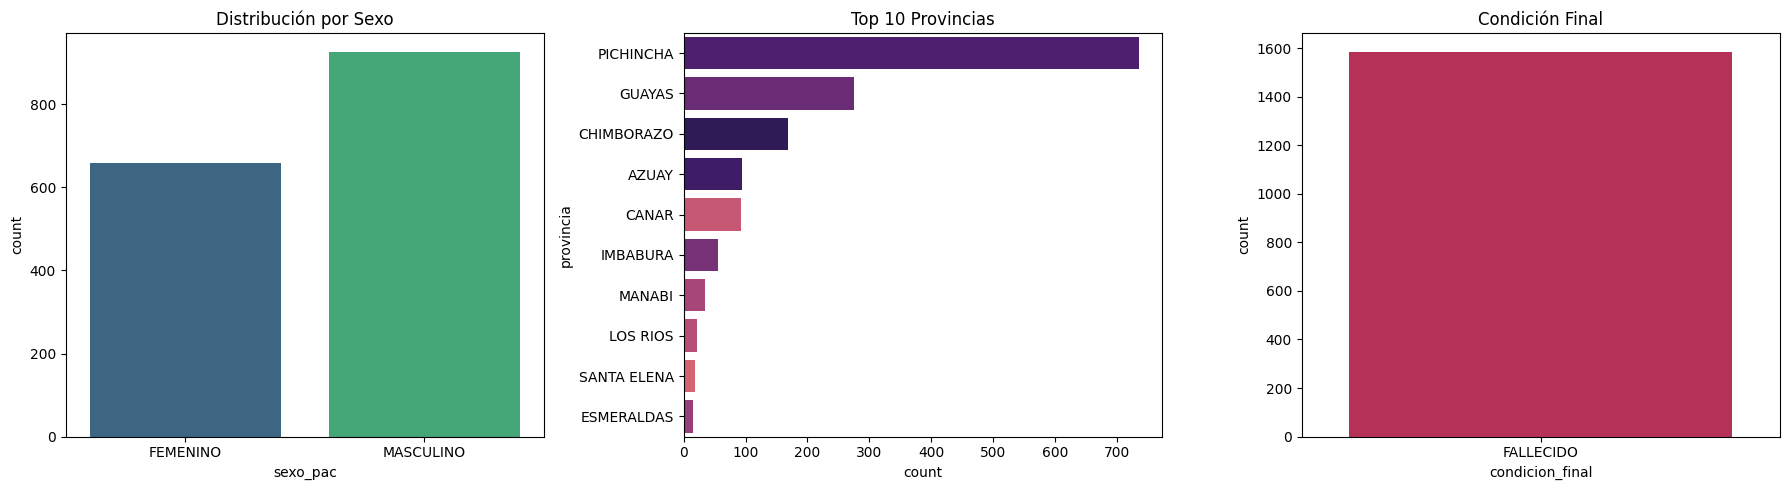


### Evolución Temporal de Casos


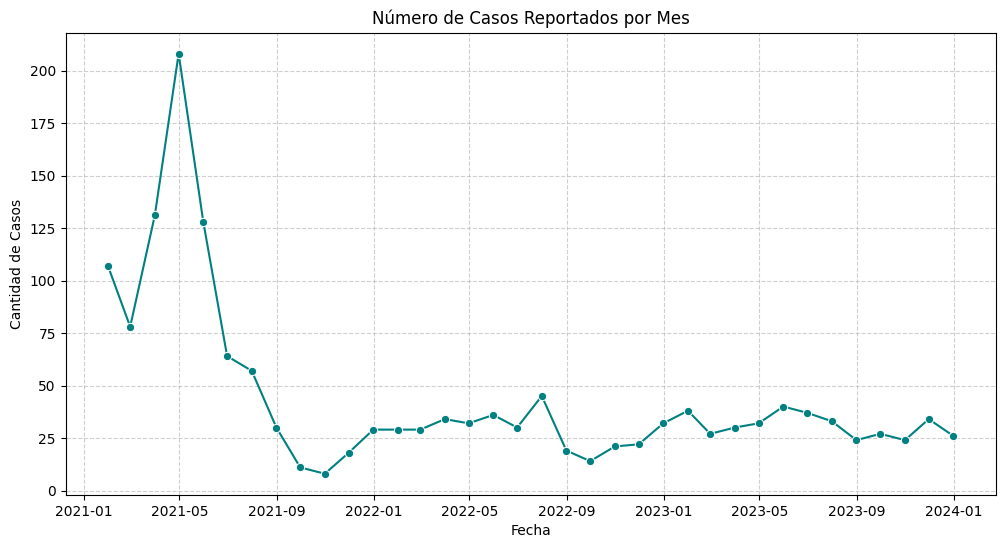

In [91]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Estadística Descriptiva
print("### Estadística Descriptiva de Variables Numéricas")
display(df.describe())

# 2. Análisis de Variables Categóricas
print("\n### Distribución de Variables Categóricas Principales")
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.countplot(data=df, x='sexo_pac', ax=axes[0], palette='viridis', hue='sexo_pac', legend=False)
axes[0].set_title('Distribución por Sexo')

sns.countplot(data=df, y='provincia', ax=axes[1], palette='magma', order=df['provincia'].value_counts().index[:10], hue='provincia', legend=False)
axes[1].set_title('Top 10 Provincias')

sns.countplot(data=df, x='condicion_final', ax=axes[2], palette='rocket', hue='condicion_final', legend=False)
axes[2].set_title('Condición Final')

plt.tight_layout()
plt.show()

# 3. Análisis de Variables Temporales
print("\n### Evolución Temporal de Casos")
# 'fecha_caso_pac' ya es un objeto datetime debido a la limpieza de datos
df_temp = df.set_index('fecha_caso_pac').resample('ME').size().reset_index(name='conteo')

plt.figure(figsize=(12, 6))
sns.lineplot(data=df_temp, x='fecha_caso_pac', y='conteo', marker='o', color='teal')
plt.title('Número de Casos Reportados por Mes')
plt.xlabel('Fecha')
plt.ylabel('Cantidad de Casos')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

### Resumen de Variables Categóricas

Este resumen proporciona una visión general de las variables categóricas, mostrando la cantidad de valores únicos y las top 5 categorías con sus respectivas frecuencias para cada una. Esto nos ayuda a entender la distribución y la diversidad de los datos cualitativos.

In [92]:
import pandas as pd

print("### Resumen de Variables Categóricas\n")

categorical_cols = df.select_dtypes(include='object').columns

for col in categorical_cols:
    print(f"--- Columna: '{col}' ---")
    print(f"Número de valores únicos: {df[col].nunique()}")
    print("Top 5 categorías:")
    display(df[col].value_counts().head().to_frame())
    print("\n")

### Resumen de Variables Categóricas

--- Columna: 'unidad_operativa' ---
Número de valores únicos: 18
Top 5 categorías:


,count
unidad_operativa,
HOSPITAL EUGENIO ESPEJO,345
HOSPITAL CARLOS ANDRADE MARIN (IESS),284
HOSPITAL GENERAL DOCENTE RIOBAMBA,167
HOSPITAL DEL NIÑO DR.FRANCISCO ICAZA BUSTAMANTE,161
HOSPITAL DE INFECTOLOGIA Y DERMATOLOGICO,146




--- Columna: 'tipo_atencion' ---
Número de valores únicos: 1
Top 5 categorías:


,count
tipo_atencion,
HOSPTALIZACION,1584




--- Columna: 'nacionalidad' ---
Número de valores únicos: 1
Top 5 categorías:


...

,count
fecha_muestra_procesada,
20/4/2021,24
12/4/2021,20
13/4/2021,13
19/4/2021,12
9/3/2021,12




--- Columna: 'resultado_laboratorio' ---
Número de valores únicos: 2
Top 5 categorías:


,count
resultado_laboratorio,
NEGATIVO,930
POSITIVO,654




--- Columna: 'agente_epidemiologico' ---
Número de valores únicos: 9
Top 5 categorías:


,count
agente_epidemiologico,
NEGATIVO,930
SARS COV2,559
A/H1N1 2009,24
INFLUENZA B,20
VSR,19


### Análisis de Frecuencia de Categorías

In [93]:
print('### Análisis Completo de Frecuencia de Categorías por Variable\n')

categorical_cols = df.select_dtypes(include='object').columns

for col in categorical_cols:
    print(f"--- Columna: '{col}' ---")
    display(df[col].value_counts().to_frame())
    print("\n")

### Análisis Completo de Frecuencia de Categorías por Variable

--- Columna: 'unidad_operativa' ---


,count
unidad_operativa,
HOSPITAL EUGENIO ESPEJO,345
HOSPITAL CARLOS ANDRADE MARIN (IESS),284
HOSPITAL GENERAL DOCENTE RIOBAMBA,167
HOSPITAL DEL NIÑO DR.FRANCISCO ICAZA BUSTAMANTE,161
HOSPITAL DE INFECTOLOGIA Y DERMATOLOGICO,146
HOSPITAL HOMERO CASTAÑER CRESPO,100
HOSPITAL VICENTE CORRAL MOSCOSO,99
HOSPITAL DE NIÑOS BACA ORTIZ,87
HOSPITAL DEL SUR ENRIQUE GARCES,83




--- Columna: 'tipo_atencion' ---


,count
tipo_atencion,
HOSPTALIZACION,1584




--- Columna: 'nacionalidad' ---


...

,count
fecha_muestra_procesada,
20/4/2021,24
12/4/2021,20
13/4/2021,13
19/4/2021,12
9/3/2021,12
...,...
24/6/2022,1
15/7/2022,1
31/10/2022,1




--- Columna: 'resultado_laboratorio' ---


,count
resultado_laboratorio,
NEGATIVO,930
POSITIVO,654




--- Columna: 'agente_epidemiologico' ---


,count
agente_epidemiologico,
NEGATIVO,930
SARS COV2,559
A/H1N1 2009,24
INFLUENZA B,20
VSR,19
A/H3N2,16
OTROS,8
PARAINFLUENZA III,5
ADENOVIRUS,3


### Tablas Dinámicas Analíticas

Vamos a construir tablas dinámicas para explorar las relaciones entre las variables más relevantes como `tipo_edad_pac`, `sexo_pac`, `uci` y `provincia`.

In [94]:
print('### Tabla Dinámica: Uso de UCI por Tipo de Edad y Sexo (Conteo)')
pivot_table_uci_edad_sexo = pd.pivot_table(df, values='cod_paciente', index=['tipo_edad_pac', 'sexo_pac'], columns='uci', aggfunc='count', fill_value=0)
display(pivot_table_uci_edad_sexo)

print('\nExplicación: Esta tabla muestra la cantidad de pacientes que ingresaron o no a UCI, desagregados por su tipo de edad (AÑOS, MESES, DIAS) y su sexo.')

### Tabla Dinámica: Uso de UCI por Tipo de Edad y Sexo (Conteo)


uci                       NO   SI
tipo_edad_pac sexo_pac           
AÑOS          FEMENINO   338  246
              MASCULINO  497  332
DIAS          MASCULINO    1    0
DÑAS          FEMENINO     1    1
              MASCULINO    1    3
MESES         FEMENINO    34   38
              MASCULINO   58   34


Explicación: Esta tabla muestra la cantidad de pacientes que ingresaron o no a UCI, desagregados por su tipo de edad (AÑOS, MESES, DIAS) y su sexo.


In [95]:
print('### Tabla Dinámica: Edad Homologada Promedio por Provincia y Uso de UCI')
pivot_table_edad_provincia_uci = pd.pivot_table(df, values='edad_homologada', index='provincia', columns='uci', aggfunc='mean', fill_value=0)
display(pivot_table_edad_provincia_uci)

print('\nExplicación: Aquí visualizamos la edad homologada promedio de los pacientes que estuvieron o no en UCI, agrupados por su provincia de residencia.')

### Tabla Dinámica: Edad Homologada Promedio por Provincia y Uso de UCI


uci,NO,SI
provincia,,
AZUAY,62.409722,38.765805
BOLIVAR,60.900000,10.416667
CANAR,75.729167,51.801282
CARCHI,75.000000,46.000000
CHIMBORAZO,70.011278,60.104762
COTOPAXI,46.770833,30.633333
EL ORO,18.750000,4.666667
ESMERALDAS,11.052083,22.261905
GUAYAS,29.436348,31.485931



Explicación: Aquí visualizamos la edad homologada promedio de los pacientes que estuvieron o no en UCI, agrupados por su provincia de residencia.


In [96]:
print('### Tabla Dinámica: Condición Final por Sexo y Uso de UCI')
pivot_table_condicion_sexo_uci = pd.pivot_table(df, values='cod_paciente', index=['condicion_final', 'sexo_pac'], columns='uci', aggfunc='count', fill_value=0)
display(pivot_table_condicion_sexo_uci)

print('\nExplicación: Esta tabla muestra el conteo de pacientes con su condición final, segmentado por sexo y si utilizaron UCI o no.')

### Tabla Dinámica: Condición Final por Sexo y Uso de UCI


uci                         NO   SI
condicion_final sexo_pac           
FALLECIDO       FEMENINO   373  285
                MASCULINO  557  369


Explicación: Esta tabla muestra el conteo de pacientes con su condición final, segmentado por sexo y si utilizaron UCI o no.


### Conteo de Valores Únicos por Variable

In [97]:
print('### Conteo de Variables Únicas por Columna\n')

for col in df.columns:
    print(f"--- Columna: '{col}' ---")
    print(f"Número de valores únicos: {df[col].nunique()}")
    print("\n")

### Conteo de Variables Únicas por Columna

--- Columna: 'cod_paciente' ---
Número de valores únicos: 1584


--- Columna: 'fecha_caso_pac' ---
Número de valores únicos: 685


--- Columna: 'unidad_operativa' ---
Número de valores únicos: 18


--- Columna: 'tipo_atencion' ---
Número de valores únicos: 1


--- Columna: 'fecha_hospitalizacion' ---
Número de valores únicos: 714


--- Columna: 'nacionalidad' ---
Número de valores únicos: 1


--- Columna: 'provincia' ---
Número de valores únicos: 23


--- Columna: 'canton' ---
Número de valores únicos: 150


--- Columna: 'sexo_pac' ---
Número de valores únicos: 2


--- Columna: 'edad_pac' ---
Número de valores únicos: 100


--- Columna: 'tipo_edad_pac' ---
Número de valores únicos: 4


--- Columna: 'inicio_fiebre' ---
Número de valores únicos: 719


--- Columna: 'semana_epi' ---
Número de valores únicos: 53


--- Columna: 'comorbilidad' ---
Número de valores únicos: 2


--- Columna: 'antecedente_viaje' ---
Número de valores únicos: 2


--- Co

### Ordenamiento de Datos para Identificación de Patrones y Extremos

In [98]:
print('### Pacientes con Menor Edad Homologada (Valores Extremos Inferiores)\n')
display(df.sort_values(by='edad_homologada', ascending=True).head())

print('\n### Pacientes con Mayor Edad Homologada (Valores Extremos Superiores)\n')
display(df.sort_values(by='edad_homologada', ascending=False).head())

### Pacientes con Menor Edad Homologada (Valores Extremos Inferiores)



,cod_paciente,fecha_caso_pac,unidad_operativa,tipo_atencion,fecha_hospitalizacion,nacionalidad,provincia,canton,sexo_pac,edad_pac,...,fecha_cierre,tipo_muestra_laboratorio,fecha_toma_laboratorio,fecha_recepcion_laboratorio,muestra_adecuada,fecha_muestra_procesada,resultado_laboratorio,agente_epidemiologico,dias_evolucion_pre_hosp,edad_homologada
608,46642,2022-02-13,HOSPITAL VERDI CEVALLOS,HOSPTALIZACION,2022-01-27,ECUADOR,MANABI,MANTA,MASCULINO,21,...,28/3/2022,ASPIRADO NASOFARINGEO TRAQUEAL,13/2/2022,15/2/2022,SI,16/2/2022,NEGATIVO,NEGATIVO,0,0.057534
50,58042,2023-10-25,HOSPITAL DE NIÑOS BACA ORTIZ,HOSPTALIZACION,2023-10-24,ECUADOR,PICHINCHA,QUITO,FEMENINO,1,...,5/1/2024,HISOPADO NASOFARINGEO,25/10/2023,26/10/2023,SI,26/10/2023,NEGATIVO,NEGATIVO,0,0.083333
1552,47541,2022-04-27,HOSPITAL DEL NIÑO DR.FRANCISCO ICAZA BUSTAMANTE,HOSPTALIZACION,2022-04-27,ECUADOR,GUAYAS,PALESTINA,MASCULINO,1,...,6/6/2022,HISOPADO NASOFARINGEO,27/4/2022,29/4/2022,SI,3/5/2022,NEGATIVO,NEGATIVO,11,0.083333
1551,47492,2022-04-22,HOSPITAL DEL NIÑO DR.FRANCISCO ICAZA BUSTAMANTE,HOSPTALIZACION,2022-04-22,ECUADOR,GUAYAS,GUAYAQUIL,MASCULINO,1,...,12/5/2022,HISOPADO NASOFARINGEO,22/4/2022,25/4/2022,SI,26/4/2022,NEGATIVO,NEGATIVO,0,0.083333
774,57430,2023-09-15,HOSPITAL DEL NIÑO DR.FRANCISCO ICAZA BUSTAMANTE,HOSPTALIZACION,2023-09-15,ECUADOR,GUAYAS,GUAYAQUIL,FEMENINO,1,...,5/10/2023,HISOPADO NASOFARINGEO,16/9/2023,19/9/2023,SI,19/9/2023,NEGATIVO,NEGATIVO,1,0.083333



### Pacientes con Mayor Edad Homologada (Valores Extremos Superiores)



,cod_paciente,fecha_caso_pac,unidad_operativa,tipo_atencion,fecha_hospitalizacion,nacionalidad,provincia,canton,sexo_pac,edad_pac,...,fecha_cierre,tipo_muestra_laboratorio,fecha_toma_laboratorio,fecha_recepcion_laboratorio,muestra_adecuada,fecha_muestra_procesada,resultado_laboratorio,agente_epidemiologico,dias_evolucion_pre_hosp,edad_homologada
1449,42700,2021-02-08,HOSPITAL HOMERO CASTAÑER CRESPO,HOSPTALIZACION,2021-02-08,ECUADOR,CANAR,AZOGUES,FEMENINO,103,...,23/9/2021,ASPIRADO NASOFARINGEO TRAQUEAL,10/2/2021,11/2/2021,SI,11/2/2021,NEGATIVO,NEGATIVO,4,103.0
1099,44506,2021-05-28,HOSPITAL GENERAL DOCENTE RIOBAMBA,HOSPTALIZACION,2021-05-28,ECUADOR,CHIMBORAZO,RIOBAMBA,FEMENINO,103,...,9/6/2021,HISOPADO NASOFARINGEO,28/5/2021,31/5/2021,SI,1/6/2021,POSITIVO,SARS COV2,5,103.0
1338,44836,2021-05-10,HOSPITAL HOMERO CASTAÑER CRESPO,HOSPTALIZACION,2021-05-08,ECUADOR,CANAR,AZOGUES,MASCULINO,99,...,23/9/2021,HISOPADO NASOFARINGEO,8/5/2021,12/5/2021,SI,12/5/2021,NEGATIVO,NEGATIVO,7,99.0
1363,44847,2021-05-26,HOSPITAL HOMERO CASTAÑER CRESPO,HOSPTALIZACION,2021-05-26,ECUADOR,CANAR,AZOGUES,FEMENINO,98,...,23/9/2021,HISOPADO NASOFARINGEO,26/5/2021,26/5/2021,SI,26/7/2021,NEGATIVO,NEGATIVO,1,98.0
466,43552,2021-04-12,HOSPITAL CARLOS ANDRADE MARIN (IESS),HOSPTALIZACION,2021-04-11,ECUADOR,PICHINCHA,QUITO,FEMENINO,98,...,24/4/2021,HISOPADO NASOFARINGEO,12/4/2021,12/4/2021,SI,12/4/2021,NEGATIVO,NEGATIVO,1,98.0


### Análisis de Correlación entre Edad Homologada y Variables Numéricas

Realizaremos un mapa de calor para visualizar la correlación entre la `edad_homologada` y otras variables numéricas presentes en el dataset. Esto nos ayudará a identificar relaciones lineales y posibles factores influyentes.

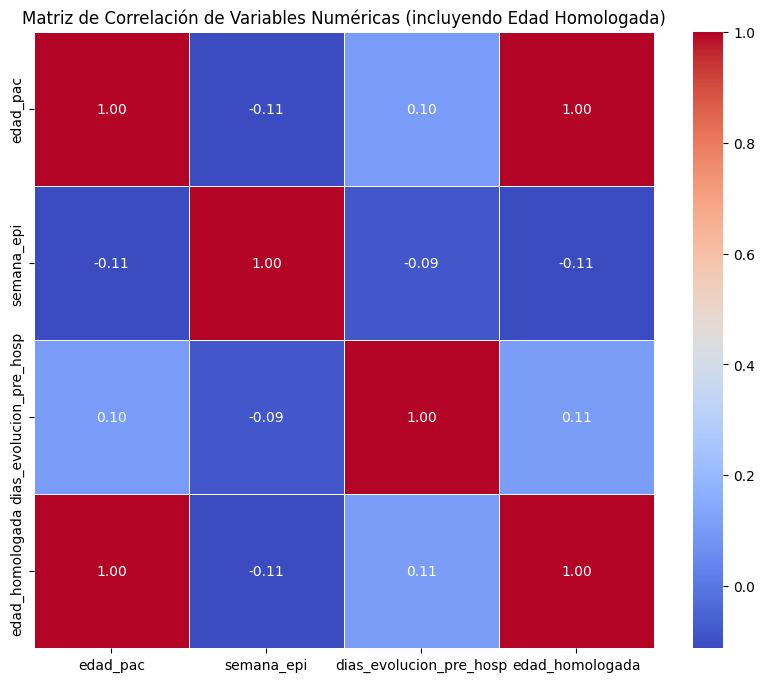


--- Correlación de 'edad_homologada' con otras variables --- 


,edad_homologada
edad_homologada,1.000000
edad_pac,0.998755
dias_evolucion_pre_hosp,0.106661
semana_epi,-0.111581


In [99]:
import matplotlib.pyplot as plt
import seaborn as sns

# Seleccionar solo columnas numéricas para el análisis de correlación
# Excluir 'cod_paciente' ya que es un identificador y no una medida cuantitativa para correlación
numerical_cols = df.select_dtypes(include=['int64', 'float64']).drop(columns=['cod_paciente'], errors='ignore')

# Calcular la matriz de correlación
corr_matrix = numerical_cols.corr()

# Visualizar la matriz de correlación usando un mapa de calor
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Matriz de Correlación de Variables Numéricas (incluyendo Edad Homologada)')
plt.show()

print("\n--- Correlación de 'edad_homologada' con otras variables --- ")
display(corr_matrix['edad_homologada'].sort_values(ascending=False))

### Gráfico de Dispersión: Edad Homologada vs. Semana Epidemiológica

Este gráfico nos ayudará a visualizar la distribución de los casos en función de la edad del paciente y la semana epidemiológica, permitiendo identificar posibles patrones o agrupaciones.

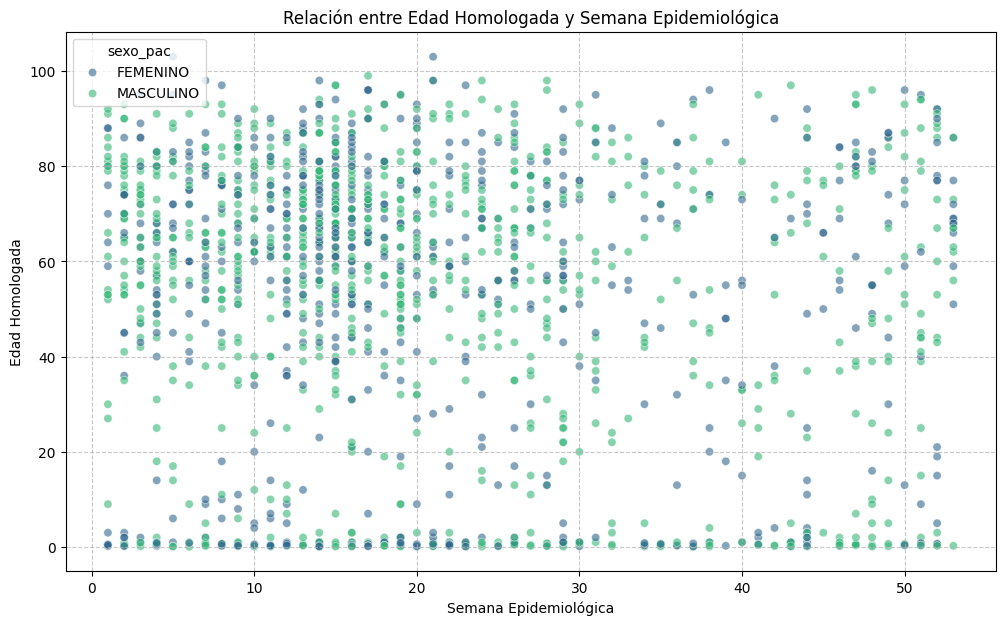

In [100]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 7))
sns.scatterplot(data=df, x='semana_epi', y='edad_homologada', alpha=0.6, hue='sexo_pac', palette='viridis')
plt.title('Relación entre Edad Homologada y Semana Epidemiológica')
plt.xlabel('Semana Epidemiológica')
plt.ylabel('Edad Homologada')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

### Análisis de Valores Atípicos en 'edad_pac' mediante Boxplot

Un boxplot es una herramienta excelente para visualizar la distribución de una variable numérica e identificar la presencia de valores atípicos (outliers). Analizaremos la columna `edad_pac` para detectar cualquier edad que se desvíe significativamente de la mayoría.

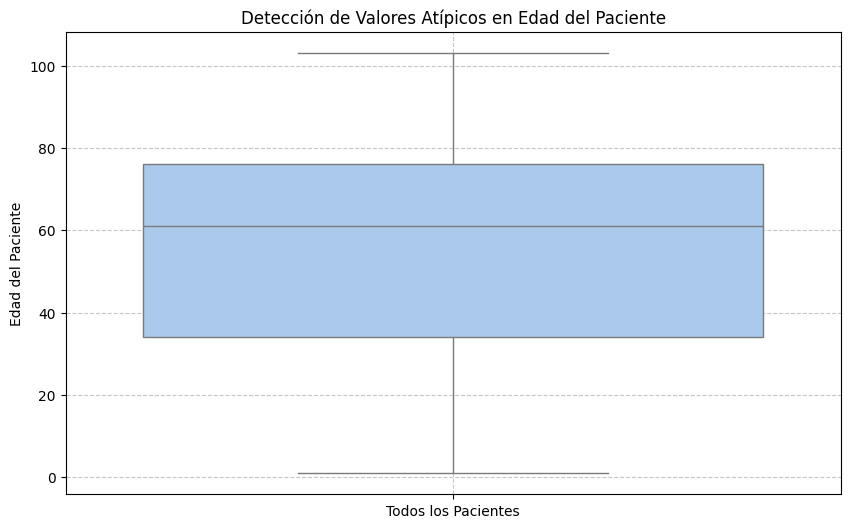

In [101]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

plt.figure(figsize=(10, 6))
# Crear una variable x ficticia para el boxplot para satisfacer la advertencia
x_constant = pd.Series('Todos los Pacientes', index=df.index)
sns.boxplot(x=x_constant, y=df['edad_pac'], palette='pastel', hue=x_constant, legend=False)
plt.title('Detección de Valores Atípicos en Edad del Paciente')
plt.ylabel('Edad del Paciente')
plt.xlabel('') # Eliminar la etiqueta del eje x ya que es una constante ficticia
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

### Análisis de Valores Nulos Restantes

Después de las etapas de limpieza, es crucial verificar si aún quedan valores nulos en el dataset y en qué columnas. Esto nos permitirá decidir si se requiere una imputación adicional o si las columnas con muchos nulos deben ser consideradas para su exclusión en análisis futuros.

In [102]:
import pandas as pd

# Calcular el porcentaje de valores nulos por columna
null_percentage = df.isnull().sum() / len(df) * 100

# Filtrar solo las columnas que tienen valores nulos y ordenar
null_percentage = null_percentage[null_percentage > 0].sort_values(ascending=False)

print("### Porcentaje de Valores Nulos Restantes por Columna:")
if null_percentage.empty:
    print("¡No hay valores nulos restantes en el dataset!")
else:
    display(null_percentage.to_frame(name='Porcentaje de Nulos'))

### Porcentaje de Valores Nulos Restantes por Columna:


,Porcentaje de Nulos
ingreso_uci,58.712121
egreso_uci,58.712121


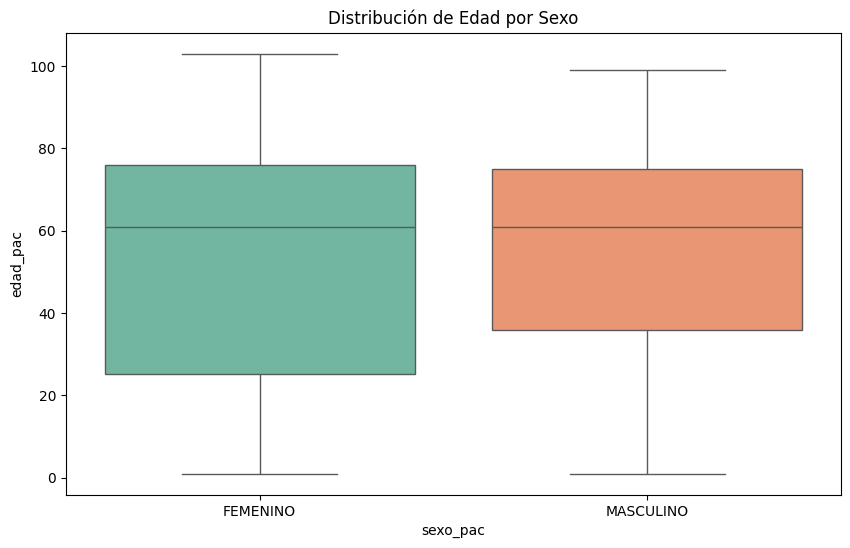

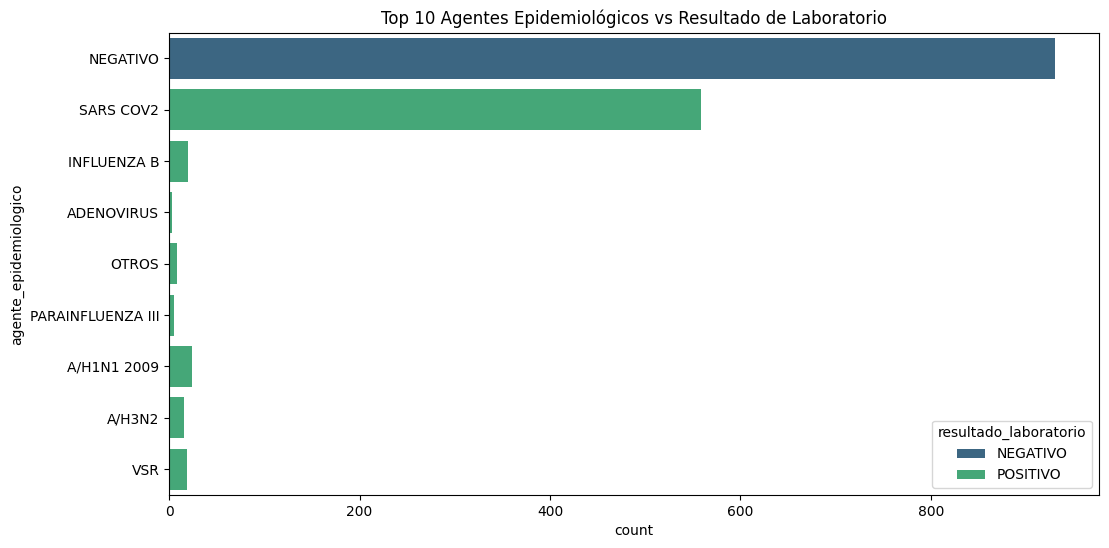

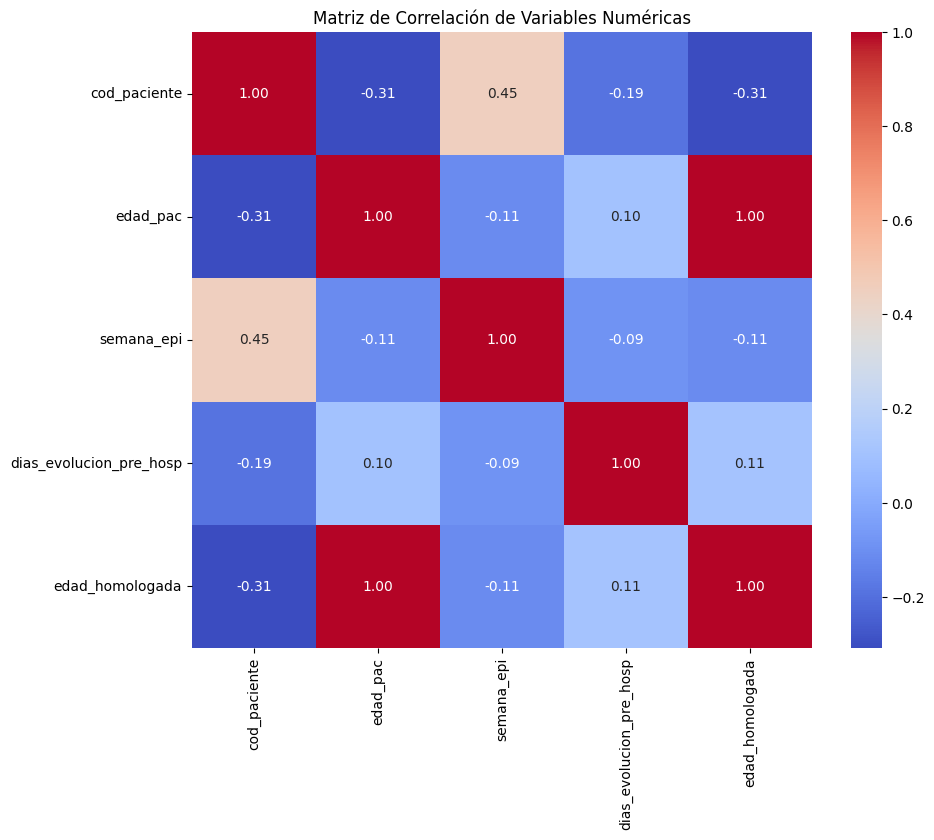

In [103]:
import plotly.express as px

# 1. Distribución de Edad por Sexo (Boxplot)
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='sexo_pac', y='edad_pac', palette='Set2', hue='sexo_pac', legend=False)
plt.title('Distribución de Edad por Sexo')
plt.show()

# 2. Resultados de Laboratorio por Agente Epidemiológico
plt.figure(figsize=(12, 6))
top_agentes = df['agente_epidemiologico'].value_counts().nlargest(10).index
sns.countplot(data=df[df['agente_epidemiologico'].isin(top_agentes)],
              y='agente_epidemiologico', hue='resultado_laboratorio', palette='viridis')
plt.title('Top 10 Agentes Epidemiológicos vs Resultado de Laboratorio')
plt.show()

# 3. Heatmap de correlación (Variables numéricas)
plt.figure(figsize=(10, 8))
corr = df.select_dtypes(include=['int64', 'float64']).corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Matriz de Correlación de Variables Numéricas')
plt.show()

### Frecuencia de la Variable 'resultado_laboratorio'

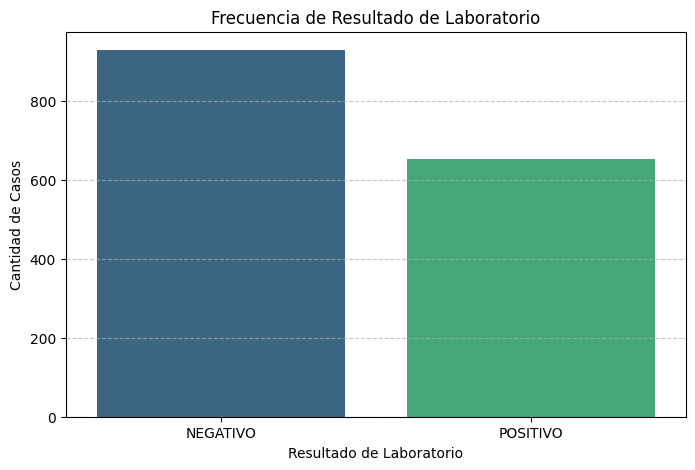

In [104]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='resultado_laboratorio', palette='viridis', hue='resultado_laboratorio', legend=False)
plt.title('Frecuencia de Resultado de Laboratorio')
plt.xlabel('Resultado de Laboratorio')
plt.ylabel('Cantidad de Casos')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

### Creación de la Variable 'Días de evolución antes de la hospitalización'

Calcularemos el número de días transcurridos entre el inicio de la fiebre (`inicio_fiebre`) y la fecha de hospitalización (`fecha_hospitalizacion`). Esta variable es crucial para entender la progresión de la enfermedad antes de que el paciente reciba atención hospitalaria.

In [105]:
# Convertir las columnas a formato datetime si no lo están ya
df['fecha_hospitalizacion'] = pd.to_datetime(df['fecha_hospitalizacion'], dayfirst=True, errors='coerce')
df['inicio_fiebre'] = pd.to_datetime(df['inicio_fiebre'], dayfirst=True, errors='coerce')

# Calcular la diferencia en días y manejar valores negativos usando assign
df = df.assign(dias_evolucion_pre_hosp=lambda x: (x['fecha_hospitalizacion'] - x['inicio_fiebre']).dt.days)
df.loc[df['dias_evolucion_pre_hosp'] < 0, 'dias_evolucion_pre_hosp'] = 0

print("Primeras 5 filas con la nueva variable 'dias_evolucion_pre_hosp' (usando assign):")
display(df[['fecha_hospitalizacion', 'inicio_fiebre', 'dias_evolucion_pre_hosp']].head())

Primeras 5 filas con la nueva variable 'dias_evolucion_pre_hosp' (usando assign):


,fecha_hospitalizacion,inicio_fiebre,dias_evolucion_pre_hosp
0,2023-11-07,2023-11-01,6
1,2022-01-26,2022-01-16,10
2,2023-03-22,2023-03-19,3
3,2023-03-07,2023-03-05,2
4,2022-10-03,2022-09-29,4


### Tiempo Máximo de Evolución antes de la Hospitalización

Identificaremos el valor máximo de `dias_evolucion_pre_hosp` para conocer la duración más larga de la evolución de la enfermedad antes de que un paciente fuera hospitalizado.

In [106]:
max_dias_evolucion = df['dias_evolucion_pre_hosp'].max()
print(f"El tiempo máximo de evolución antes de la hospitalización es: {max_dias_evolucion} días")

El tiempo máximo de evolución antes de la hospitalización es: 46 días


### Estadísticas Descriptivas de 'edad_homologada'

A continuación, se presentan las estadísticas descriptivas (media, desviación estándar, mínimos, máximos, cuartiles) de la variable `edad_homologada` a nivel global y segmentadas por `sexo_pac`. Esto nos ayudará a comprender mejor la distribución de la edad de los pacientes en el dataset.

In [107]:
import pandas as pd

print("\n### Estadísticas Globales de 'edad_homologada':")
display(df['edad_homologada'].describe())

print("\n### Estadísticas de 'edad_homologada' Segmentadas por 'sexo_pac':")
display(df.groupby('sexo_pac')['edad_homologada'].describe())


### Estadísticas Globales de 'edad_homologada':


,edad_homologada
count,1584.000000
mean,52.423490
std,29.665563
min,0.057534
25%,34.000000
50%,61.000000
75%,76.000000
max,103.000000



### Estadísticas de 'edad_homologada' Segmentadas por 'sexo_pac':


,count,mean,std,min,25%,50%,75%,max
sexo_pac,,,,,,,,
FEMENINO,658.0,51.635005,30.685565,0.083333,25.25,61.0,76.0,103.0
MASCULINO,926.0,52.983773,28.922612,0.057534,36.00,61.0,75.0,99.0


### Gráfico de Distribución y Boxplot de la Edad del Paciente

Estos gráficos nos ayudarán a comprender la distribución de la `edad_pac`, identificando su forma, asimetría, posibles modas y la presencia de valores atípicos. El histograma con KDE mostrará la densidad de la distribución, mientras que el boxplot resumirá los cuartiles y señalará los outliers.

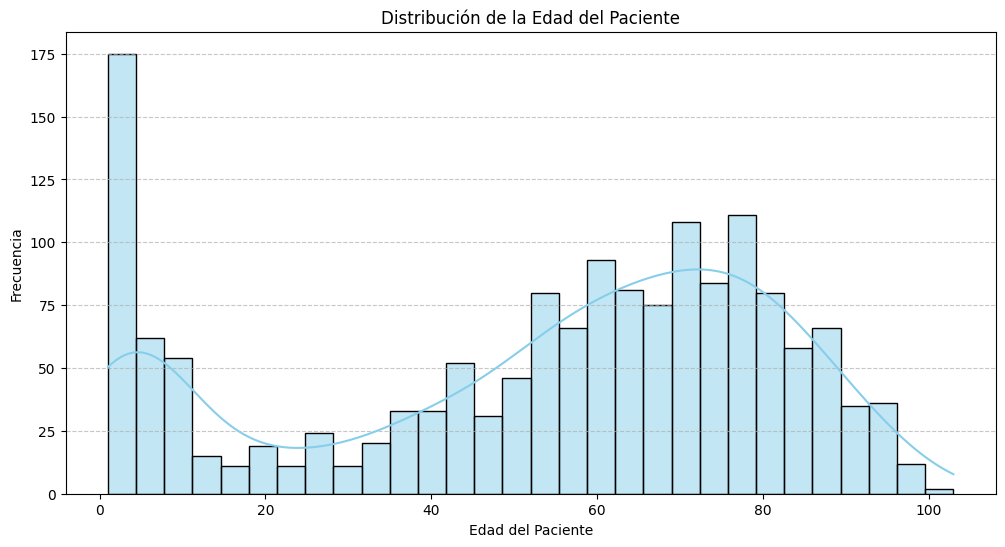

In [108]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 6))
sns.histplot(df['edad_pac'], kde=True, bins=30, color='skyblue')
plt.title('Distribución de la Edad del Paciente')
plt.xlabel('Edad del Paciente')
plt.ylabel('Frecuencia')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

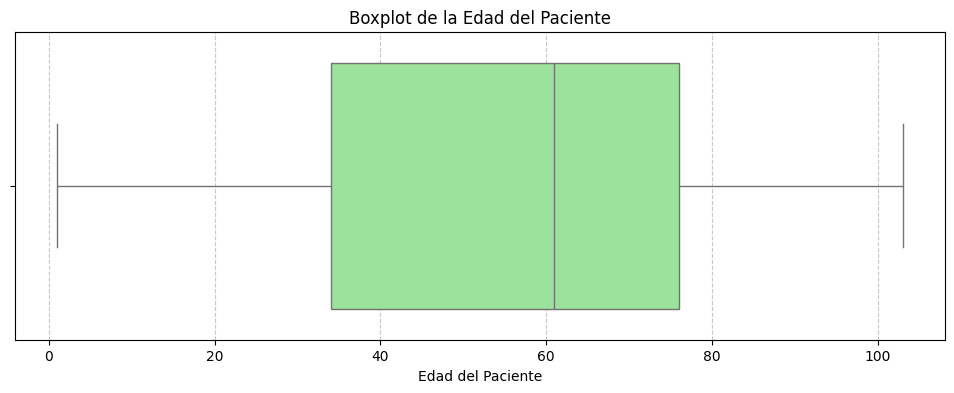

In [109]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 4))
sns.boxplot(x=df['edad_pac'], color='lightgreen')
plt.title('Boxplot de la Edad del Paciente')
plt.xlabel('Edad del Paciente')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

<a name="visualizacion-de-datos"></a>
# Visualización de Datos

### Matriz de Dispersión (Scatter Matrix) de Variables Numéricas

Una matriz de dispersión es útil para visualizar las relaciones por pares entre múltiples variables numéricas, así como la distribución individual de cada variable a través de histogramas. Analizaremos `edad_pac`, `semana_epi` y `edad_homologada`.

<Figure size 1000x800 with 0 Axes>

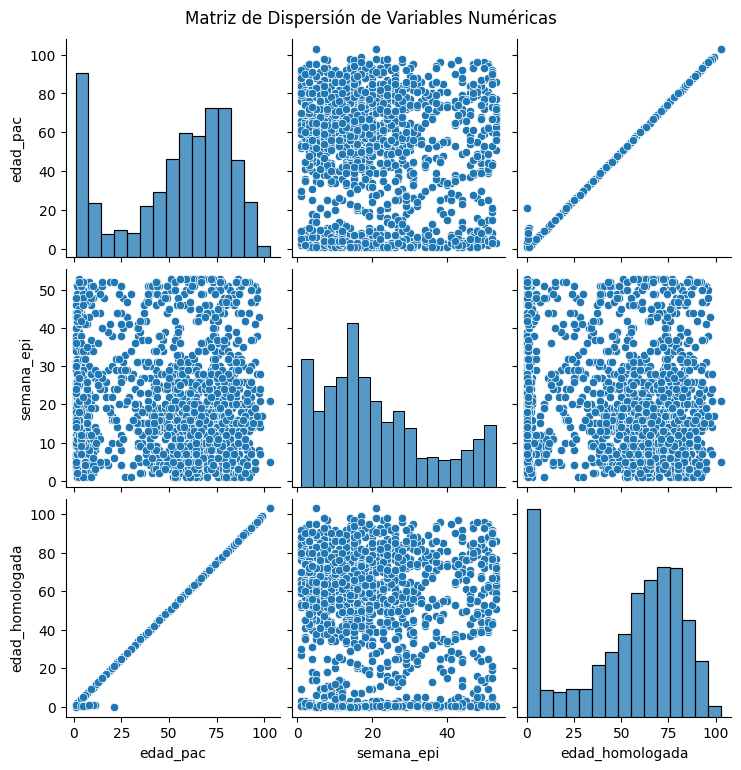

In [110]:
import matplotlib.pyplot as plt
import seaborn as sns

# Seleccionar las variables numéricas relevantes para el pairplot
numerical_features = ['edad_pac', 'semana_epi', 'edad_homologada']

# Crear el Pair Plot
plt.figure(figsize=(10, 8))
sns.pairplot(df[numerical_features])
plt.suptitle('Matriz de Dispersión de Variables Numéricas', y=1.02) # Ajustar el título para que no se solape
plt.show()

### Gráfico de Área: Acumulación de Casos por Fecha de Fallecimiento

Este gráfico de área muestra la acumulación total de casos a lo largo del tiempo, utilizando la fecha de fallecimiento. Esto permite observar la progresión y el crecimiento total de los casos reportados en el dataset.

In [111]:
import plotly.express as px
import pandas as pd

# Asegurarse de que 'fecha_fallecimiento' es de tipo datetime
df['fecha_fallecimiento'] = pd.to_datetime(df['fecha_fallecimiento'], dayfirst=True, errors='coerce')

# Contar casos por fecha de fallecimiento y ordenar
cases_by_date = df['fecha_fallecimiento'].value_counts().sort_index().reset_index()
cases_by_date.columns = ['fecha_fallecimiento', 'numero_casos']

# Calcular la suma acumulativa de casos
cases_by_date['casos_acumulados'] = cases_by_date['numero_casos'].cumsum()

# Crear el gráfico de área interactivo
fig_area = px.area(
    cases_by_date,
    x='fecha_fallecimiento',
    y='casos_acumulados',
    title='Acumulación de Casos por Fecha de Fallecimiento',
    labels={'fecha_fallecimiento': 'Fecha de Fallecimiento', 'casos_acumulados': 'Casos Acumulados'}
)

fig_area.update_layout(xaxis_title='Fecha', yaxis_title='Número Acumulado de Casos')
fig_area.show()

/tmp/ipykernel_18689/614153967.py:5: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['fecha_fallecimiento'] = pd.to_datetime(df['fecha_fallecimiento'], dayfirst=True, errors='coerce')


### Visualización Interactiva: Casos de IRAG por Provincia y Sexo

Este gráfico de barras horizontal muestra el número total de casos de IRAG en cada provincia, ordenadas de mayor a menor. Además, los casos se agrupan por sexo dentro de cada provincia, utilizando una paleta de colores específica para facilitar la identificación y el análisis interactivo.

In [112]:
import plotly.express as px
import pandas as pd

# 1. Calcular el total de casos por provincia para obtener el orden deseado (de mayor a menor)
province_totals = df['provincia'].value_counts()
province_order_desc = province_totals.index.tolist() # Lista de provincias de mayor a menor total de casos

# 2. Agrupar los datos por provincia y sexo, contando los casos
df_plot = df.groupby(['provincia', 'sexo_pac']).size().reset_index(name='count')

# 3. Definir colores personalizados para los sexos
color_map = {'MASCULINO': 'blue', 'FEMENINO': 'pink'}

# 4. Crear el gráfico de barras horizontal interactivo
fig = px.bar(
    df_plot,
    y='provincia',
    x='count',
    color='sexo_pac',
    orientation='h', # Barras horizontales
    title='Número Total de Casos de IRAG por Provincia y Sexo',
    labels={'provincia': 'Provincia', 'count': 'Número de Casos', 'sexo_pac': 'Sexo'},
    barmode='group', # Barras agrupadas para la distribución por sexo dentro de cada provincia
    color_discrete_map=color_map,
    # Asegurar que el orden de las provincias en el eje Y sea de mayor a menor número de casos
    category_orders={'provincia': province_order_desc}
)

# Actualizar el layout para una mejor legibilidad y para asegurar que la provincia con más casos esté arriba
fig.update_layout(
    xaxis_title='Número de Casos',
    yaxis_title='Provincia',
    # Plotly dibuja las categorías del eje Y de abajo hacia arriba, así que invertimos el orden
    # para que la provincia con más casos (primera en province_order_desc) aparezca en la parte superior del gráfico.
    yaxis={'categoryorder': 'array', 'categoryarray': province_order_desc[::-1]}
)

fig.show()

### Histograma de 'Días de evolución antes de la hospitalización'

Este histograma mostrará la distribución de la nueva variable `dias_evolucion_pre_hosp`, permitiéndonos identificar los rangos más comunes de días transcurridos entre el inicio de la fiebre y la hospitalización.

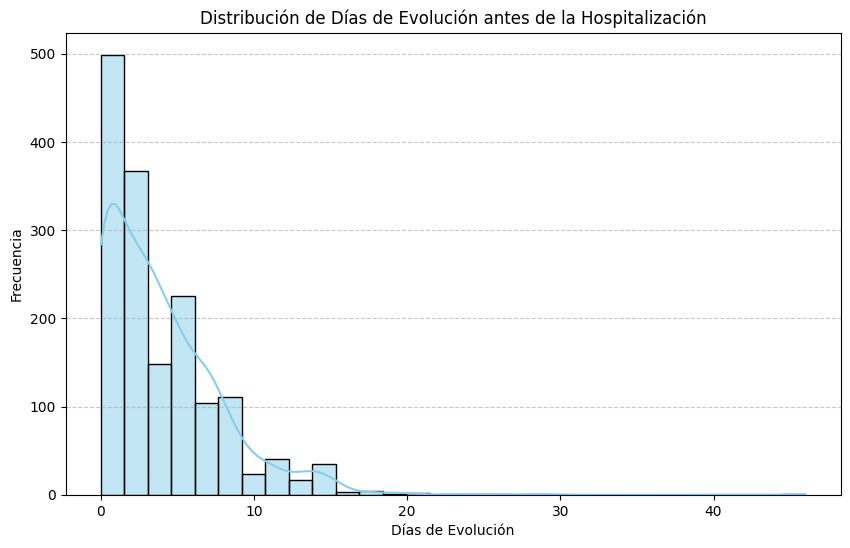

In [113]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.histplot(df['dias_evolucion_pre_hosp'].dropna(), bins=30, kde=True, color='skyblue')
plt.title('Distribución de Días de Evolución antes de la Hospitalización')
plt.xlabel('Días de Evolución')
plt.ylabel('Frecuencia')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

### Gráfico de Pastel: Distribución de Casos por Provincia

Este gráfico de pastel muestra la proporción de casos de IRAG reportados en cada provincia, proporcionando una vista rápida de las regiones con mayor incidencia.

In [114]:
import plotly.express as px

# Agrupar los datos por provincia y contar los casos
province_counts = df['provincia'].value_counts().reset_index()
province_counts.columns = ['provincia', 'cantidad_casos']

# Crear el gráfico de pastel interactivo
fig = px.pie(
    province_counts,
    values='cantidad_casos',
    names='provincia',
    title='Distribución de Casos de IRAG por Provincia',
    hover_data=['cantidad_casos'],
    labels={'provincia':'Provincia', 'cantidad_casos':'Cantidad de Casos'}
)

fig.update_traces(textposition='inside', textinfo='percent+label')
fig.show()

### Gráfico de Violin: Días de Evolución antes de Hospitalización vs. Uso de UCI

Este violin plot nos permitirá visualizar la distribución de los 'Días de evolución antes de la hospitalización' y su densidad, comparando los pacientes que ingresaron a la Unidad de Cuidados Intensivos (UCI) con aquellos que no lo hicieron. Esto puede revelar patrones en el tiempo de evolución de la enfermedad antes de la hospitalización, en función de la necesidad de UCI.

/tmp/ipykernel_18689/3969947902.py:5: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




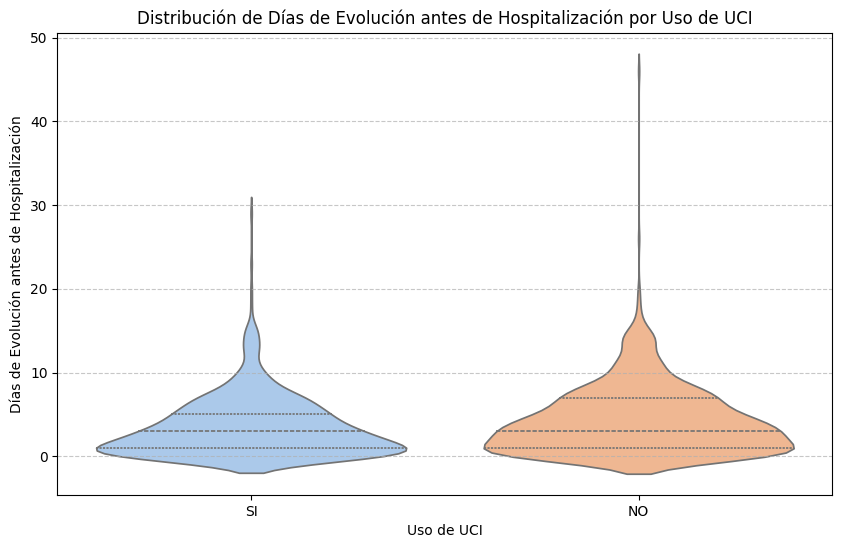

In [115]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.violinplot(x='uci', y='dias_evolucion_pre_hosp', data=df, palette='pastel', inner='quartile')
plt.title('Distribución de Días de Evolución antes de Hospitalización por Uso de UCI')
plt.xlabel('Uso de UCI')
plt.ylabel('Días de Evolución antes de Hospitalización')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

### Gráfico de Barras Apiladas: Distribución de Casos de IRAG por Provincia y Sexo

Este gráfico muestra el número total de casos de IRAG por provincia, con cada barra segmentada para representar la proporción de casos masculinos y femeninos. Las provincias se ordenan por el total de casos para una mejor comprensión visual.

In [116]:
import plotly.express as px
import pandas as pd

# 1. Calcular el total de casos por provincia para obtener el orden deseado
province_totals = df['provincia'].value_counts()
province_order_desc = province_totals.index.tolist() # Lista de provincias de mayor a menor total de casos

# 2. Agrupar los datos por provincia y sexo, contando los casos
df_plot_stacked = df.groupby(['provincia', 'sexo_pac']).size().reset_index(name='count')

# 3. Definir colores personalizados para los sexos
color_map_stacked = {'MASCULINO': 'blue', 'FEMENINO': 'pink'}

# 4. Crear el gráfico de barras apiladas interactivo
fig_stacked = px.bar(
    df_plot_stacked,
    y='provincia',
    x='count',
    color='sexo_pac',
    orientation='h', # Barras horizontales
    title='Distribución de Casos de IRAG por Provincia y Sexo',
    labels={'provincia': 'Provincia', 'count': 'Número de Casos', 'sexo_pac': 'Sexo'},
    barmode='relative', # Barras apiladas
    color_discrete_map=color_map_stacked,
    category_orders={'provincia': province_order_desc}
)

# Ajustar el layout para una mejor legibilidad y ordenar las provincias
fig_stacked.update_layout(
    xaxis_title='Número de Casos',
    yaxis_title='Provincia',
    yaxis={'categoryorder': 'array', 'categoryarray': province_order_desc[::-1]}
)

fig_stacked.show()

### TreeMap: Composición Jerárquica de Casos por Provincia y Sexo

Este TreeMap permite explorar la distribución de casos de IRAG de manera jerárquica, mostrando el total de casos por provincia y luego subdividiendo esos casos por sexo. Es útil para identificar rápidamente las provincias con mayor incidencia y la composición de género dentro de ellas.

In [117]:
import plotly.express as px
import pandas as pd

# 1. Preparar los datos para el treemap: agrupar por provincia y sexo, y contar los casos
df_treemap = df.groupby(['provincia', 'sexo_pac']).size().reset_index(name='count')

# 2. Crear el TreeMap interactivo
fig_treemap = px.treemap(
    df_treemap,
    path=[px.Constant("Total"), 'provincia', 'sexo_pac'], # Define la jerarquía: Total -> Provincia -> Sexo
    values='count',
    color='count', # Colorear por el número de casos
    color_continuous_scale='Viridis',
    title='Composición Jerárquica de Casos de IRAG por Provincia y Sexo',
    labels={'provincia': 'Provincia', 'sexo_pac': 'Sexo', 'count': 'Número de Casos'}
)

fig_treemap.update_layout(margin = dict(t=50, l=25, r=25, b=25))
fig_treemap.show()

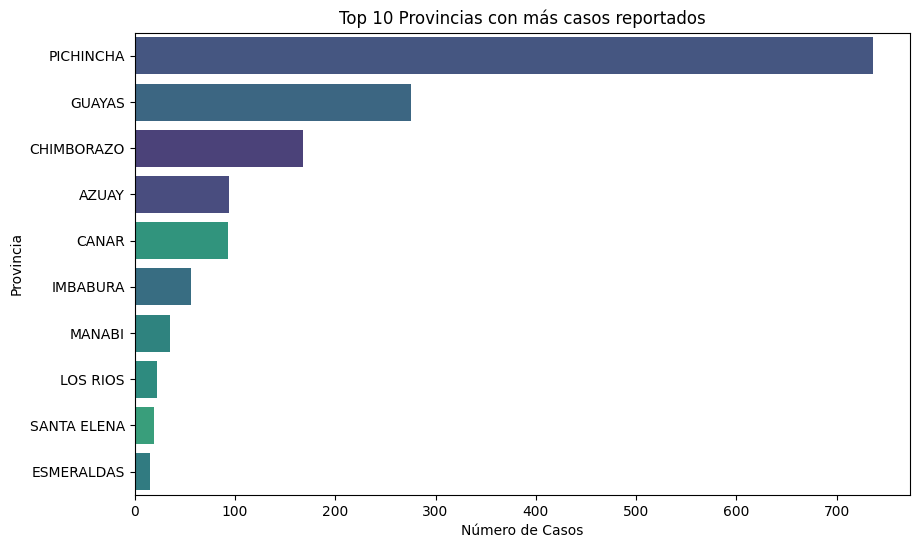

Explicación: Este gráfico muestra que la gran mayoría de los casos reportados se concentran en Pichincha y Guayas, lo cual es consistente con la densidad poblacional de estas regiones.


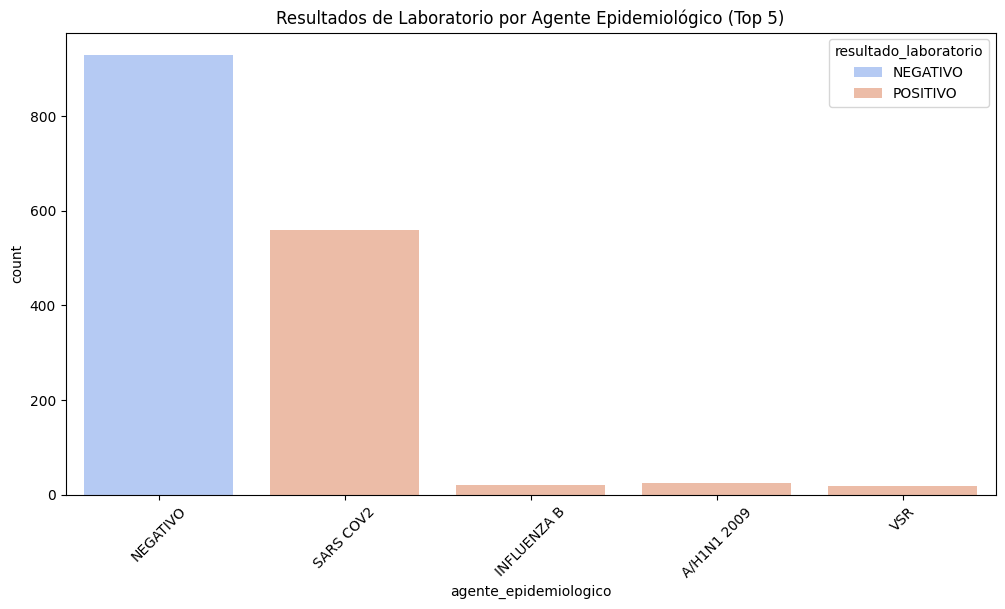

Explicación: Podemos observar que 'sars cov2' es el agente positivo más frecuente, mientras que una gran parte de las muestras resultan 'negativo' o indeterminadas.


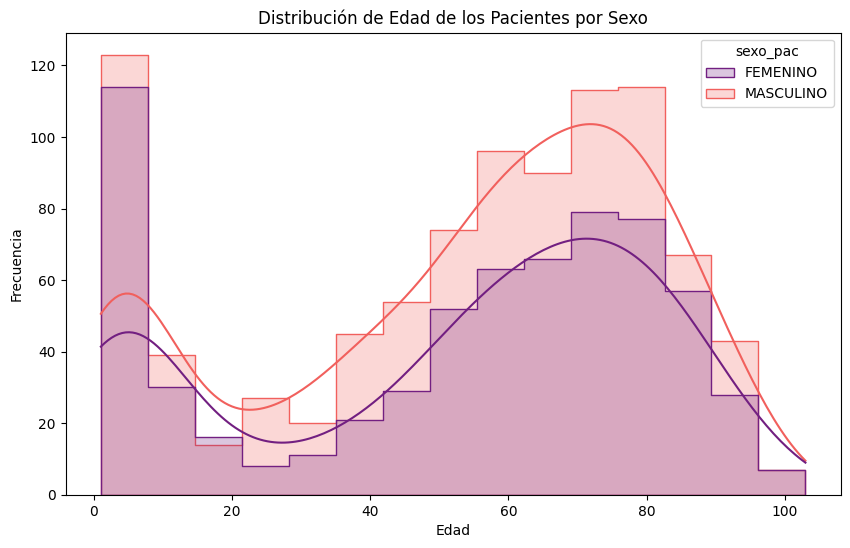

Explicación: La distribución muestra que la mayoría de los casos ocurren en adultos mayores (pico entre 60 y 80 años), con una distribución similar entre hombres y mujeres, aunque con una ligera predominancia masculina en ciertos rangos.


In [118]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Distribución por Provincias (Top 10)
plt.figure(figsize=(10, 6))
sns.countplot(data=df, y='provincia', order=df['provincia'].value_counts().iloc[:10].index, hue='provincia', palette='viridis', legend=False)
plt.title('Top 10 Provincias con más casos reportados')
plt.xlabel('Número de Casos')
plt.ylabel('Provincia')
plt.show()
print("Explicación: Este gráfico muestra que la gran mayoría de los casos reportados se concentran en Pichincha y Guayas, lo cual es consistente con la densidad poblacional de estas regiones.")

# 2. Relación entre Agente Epidemiológico y Resultado
plt.figure(figsize=(12, 6))
top_agentes = df['agente_epidemiologico'].value_counts().nlargest(5).index
sns.countplot(data=df[df['agente_epidemiologico'].isin(top_agentes)],
              x='agente_epidemiologico', hue='resultado_laboratorio', palette='coolwarm')
plt.title('Resultados de Laboratorio por Agente Epidemiológico (Top 5)')
plt.xticks(rotation=45)
plt.show()
print("Explicación: Podemos observar que 'sars cov2' es el agente positivo más frecuente, mientras que una gran parte de las muestras resultan 'negativo' o indeterminadas.")

# 3. Distribución de Edad por Sexo
plt.figure(figsize=(10, 6))
sns.histplot(data=df, x='edad_pac', hue='sexo_pac', kde=True, element='step', palette='magma')
plt.title('Distribución de Edad de los Pacientes por Sexo')
plt.xlabel('Edad')
plt.ylabel('Frecuencia')
plt.show()
print("Explicación: La distribución muestra que la mayoría de los casos ocurren en adultos mayores (pico entre 60 y 80 años), con una distribución similar entre hombres y mujeres, aunque con una ligera predominancia masculina en ciertos rangos.")

### Análisis de Relación entre Tipo de Edad y UCI

In [119]:
print('### Tabla de Contingencia: Tipo de Edad vs. UCI (Actualizado)\n')
contingency_table = pd.crosstab(df['tipo_edad_pac'], df['uci'])
display(contingency_table)

print('\n### Porcentaje de Uso de UCI por Tipo de Edad (Actualizado)\n')
display(contingency_table.apply(lambda r: r/r.sum(), axis=1))

### Tabla de Contingencia: Tipo de Edad vs. UCI (Actualizado)



uci,NO,SI
tipo_edad_pac,,
AÑOS,835,578
DIAS,1,0
DÑAS,2,4
MESES,92,72



### Porcentaje de Uso de UCI por Tipo de Edad (Actualizado)



uci,NO,SI
tipo_edad_pac,,
AÑOS,0.590941,0.409059
DIAS,1.000000,0.000000
DÑAS,0.333333,0.666667
MESES,0.560976,0.439024


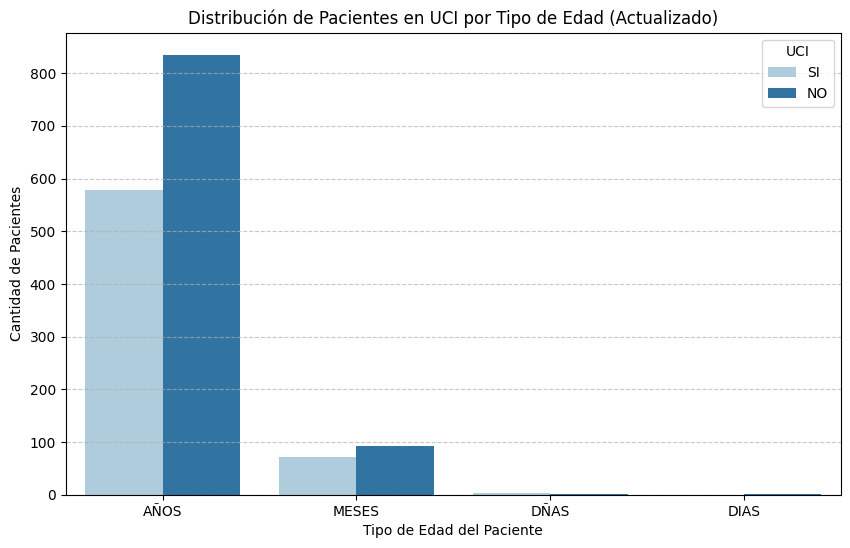

In [120]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.countplot(data=df, x='tipo_edad_pac', hue='uci', palette='Paired')
plt.title('Distribución de Pacientes en UCI por Tipo de Edad (Actualizado)')
plt.xlabel('Tipo de Edad del Paciente')
plt.ylabel('Cantidad de Pacientes')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.legend(title='UCI')
plt.show()

In [121]:
print("Valores únicos de 'tipo_edad_pac' después de la limpieza:")
display(df['tipo_edad_pac'].unique())

Valores únicos de 'tipo_edad_pac' después de la limpieza:


array(['AÑOS', 'MESES', 'DÑAS', 'DIAS'], dtype=object)

In [122]:
print('### Tabla de Contingencia: Tipo de Edad vs. UCI\n')
contingency_table = pd.crosstab(df['tipo_edad_pac'], df['uci'])
display(contingency_table)

print('\n### Porcentaje de Uso de UCI por Tipo de Edad\n')
display(contingency_table.apply(lambda r: r/r.sum(), axis=1))

### Tabla de Contingencia: Tipo de Edad vs. UCI



uci,NO,SI
tipo_edad_pac,,
AÑOS,835,578
DIAS,1,0
DÑAS,2,4
MESES,92,72



### Porcentaje de Uso de UCI por Tipo de Edad



uci,NO,SI
tipo_edad_pac,,
AÑOS,0.590941,0.409059
DIAS,1.000000,0.000000
DÑAS,0.333333,0.666667
MESES,0.560976,0.439024


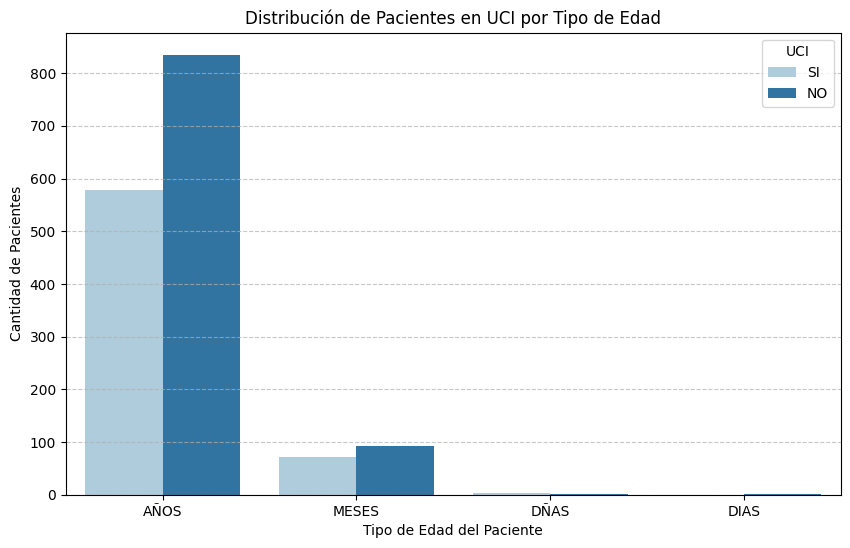

In [123]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.countplot(data=df, x='tipo_edad_pac', hue='uci', palette='Paired')
plt.title('Distribución de Pacientes en UCI por Tipo de Edad')
plt.xlabel('Tipo de Edad del Paciente')
plt.ylabel('Cantidad de Pacientes')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.legend(title='UCI')
plt.show()

<a name="machine-learning-ml"></a>
# Machine Learning (ML)

### Selección y Codificación de Variables Predictoras (Features)

Se seleccionan las variables `edad_homologada`, `sexo_pac` y `provincia` como características de entrada para el modelo. Las variables categóricas (`sexo_pac` y `provincia`) se transforman utilizando One-Hot Encoding para convertirlas en un formato numérico adecuado para el entrenamiento del modelo. `drop_first=True` se usa para evitar la trampa de las variables ficticias (dummy variable trap).

In [124]:
import pandas as pd

# Definir las variables predictoras
features_selected = ['edad_homologada', 'sexo_pac', 'provincia']

# Crear un DataFrame con solo las variables seleccionadas
X = df[features_selected].copy()

# Aplicar One-Hot Encoding a las variables categóricas con drop_first=True
X = pd.get_dummies(X, columns=['sexo_pac', 'provincia'], drop_first=True)

print("Primeras 5 filas de las variables predictoras (X) después de One-Hot Encoding:")
display(X.head())

print("\nDimensiones del DataFrame de features (X):")
print(X.shape)

Primeras 5 filas de las variables predictoras (X) después de One-Hot Encoding:


,edad_homologada,sexo_pac_MASCULINO,provincia_BOLIVAR,provincia_CANAR,provincia_CARCHI,provincia_CHIMBORAZO,provincia_COTOPAXI,provincia_EL ORO,provincia_ESMERALDAS,provincia_GUAYAS,...,provincia_MORONA SANTIAGO,provincia_NAPO,provincia_ORELLANA,provincia_PASTAZA,provincia_PICHINCHA,provincia_SANTA ELENA,provincia_STO. DOMINGO DE LOS TSACHILAS,provincia_SUCUMBIOS,provincia_TUNGURAHUA,provincia_ZAMORA CHINCHIPE
0,1.000000,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,True,False,False
1,1.000000,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,True,False,False
2,9.000000,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,True,False,False
3,0.583333,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,True
4,0.250000,False,False,False,False,False,False,False,False,False,...,True,False,False,False,False,False,False,False,False,False



Dimensiones del DataFrame de features (X):
(1584, 24)


### Preparación de la Variable Objetivo y División de Datos

En esta sección, definimos la variable objetivo `y` (`comorbilidad`), la codificamos para el modelo de Machine Learning y luego dividimos el dataset en conjuntos de entrenamiento (80%) y prueba (20%) para evaluar el modelo de manera imparcial. `random_state=42` garantiza la reproducibilidad de la división.

In [125]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

# Definir la variable objetivo (y)
y = df['comorbilidad'].copy()

# Codificar la variable objetivo 'comorbilidad'
# Asumiendo 'SI' es 1 y 'NO' es 0, o similar
le_comorbilidad = LabelEncoder()
y = le_comorbilidad.fit_transform(y)

# Dividir el dataset en conjuntos de entrenamiento y prueba
# X ya contiene las features procesadas con One-Hot Encoding
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Dimensiones del conjunto de entrenamiento X_train: {X_train.shape}")
print(f"Dimensiones del conjunto de prueba X_test: {X_test.shape}")
print(f"Dimensiones de la variable objetivo de entrenamiento y_train: {y_train.shape}")
print(f"Dimensiones de la variable objetivo de prueba y_test: {y_test.shape}")

print("\nClases codificadas para 'comorbilidad':")
for i, class_name in enumerate(le_comorbilidad.classes_):
    print(f"  {class_name}: {i}")

Dimensiones del conjunto de entrenamiento X_train: (1267, 24)
Dimensiones del conjunto de prueba X_test: (317, 24)
Dimensiones de la variable objetivo de entrenamiento y_train: (1267,)
Dimensiones de la variable objetivo de prueba y_test: (317,)

Clases codificadas para 'comorbilidad':
  NO: 0
  SI: 1


### Entrenamiento y Evaluación del Modelo de Árbol de Decisión

Instanciamos y entrenamos un `DecisionTreeClassifier` con `max_depth=5` para controlar la complejidad y evitar el sobreajuste. Luego, evaluamos su rendimiento en el conjunto de prueba utilizando la precisión (Accuracy) y un reporte de clasificación detallado.

In [126]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report

# Instanciar el modelo de Árbol de Decisión
# max_depth=5 para limitar la complejidad y mejorar la interpretabilidad
model_dt = DecisionTreeClassifier(max_depth=5, random_state=42)

# Entrenar el modelo
model_dt.fit(X_train, y_train)

# Realizar predicciones en el conjunto de prueba
y_pred_dt = model_dt.predict(X_test)

# Evaluar el modelo
accuracy_dt = accuracy_score(y_test, y_pred_dt)
print(f"\nPrecisión General (Accuracy) del Árbol de Decisión: {accuracy_dt:.4f}")

print("\nReporte de Clasificación del Árbol de Decisión:")
print(classification_report(y_test, y_pred_dt, target_names=le_comorbilidad.classes_))


Precisión General (Accuracy) del Árbol de Decisión: 0.5931

Reporte de Clasificación del Árbol de Decisión:
              precision    recall  f1-score   support

          NO       0.71      0.22      0.33       148
          SI       0.57      0.92      0.71       169

    accuracy                           0.59       317
   macro avg       0.64      0.57      0.52       317
weighted avg       0.64      0.59      0.53       317



### Importancia de las Variables (Feature Importance)

Para entender qué características influyen más en las predicciones del modelo, analizamos la importancia de las variables (Feature Importance). Esto nos ayudará a identificar qué `features` son más relevantes para determinar la `comorbilidad` según nuestro Árbol de Decisión.

Importancia de las Variables Predictoras (Árbol de Decisión):


,Feature,Importance
0,edad_homologada,0.748027
18,provincia_PICHINCHA,0.069598
5,provincia_CHIMBORAZO,0.067817
9,provincia_GUAYAS,0.057906
3,provincia_CANAR,0.014245
17,provincia_PASTAZA,0.012830
7,provincia_EL ORO,0.012646
13,provincia_MANABI,0.010827
1,sexo_pac_MASCULINO,0.006103
6,provincia_COTOPAXI,0.000000


/tmp/ipykernel_18689/1289119626.py:22: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.




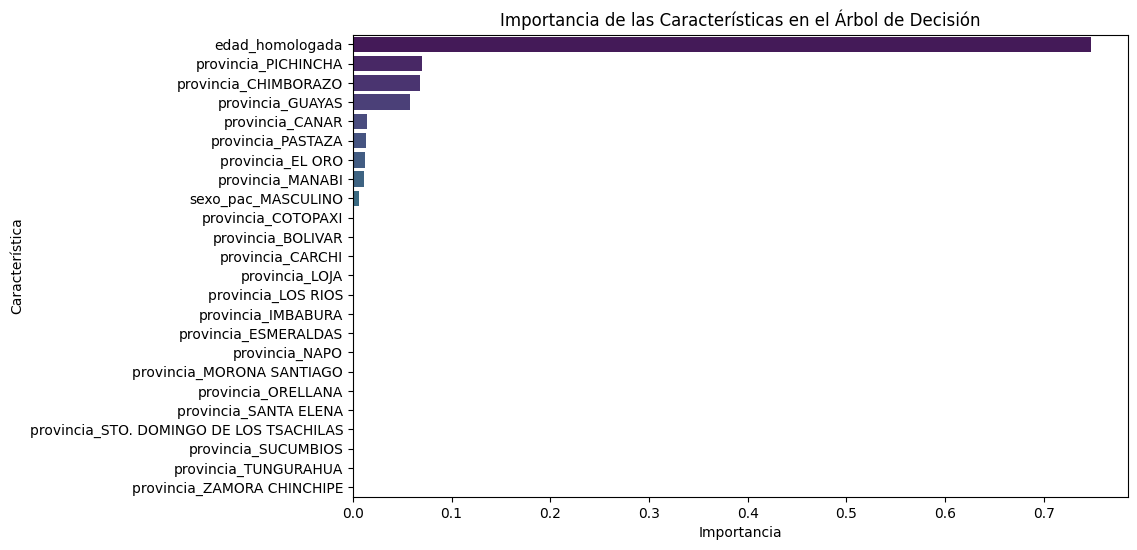

In [127]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

# Obtener la importancia de las características
feature_importances = model_dt.feature_importances_

# Crear un DataFrame para visualizar mejor las importancias
features_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': feature_importances
})

# Ordenar las características por importancia de forma descendente
features_df = features_df.sort_values(by='Importance', ascending=False)

print("Importancia de las Variables Predictoras (Árbol de Decisión):")
display(features_df)

# Visualizar la importancia de las características
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=features_df, palette='viridis')
plt.title('Importancia de las Características en el Árbol de Decisión')
plt.xlabel('Importancia')
plt.ylabel('Característica')
plt.show()

### Visualización del Árbol de Decisión

Este gráfico representa el `DecisionTreeClassifier` entrenado, mostrando los nodos de decisión, las condiciones para las divisiones, las clases predichas en cada hoja y la importancia relativa de las características. La limitación de `max_depth=5` hace que el árbol sea más interpretable.

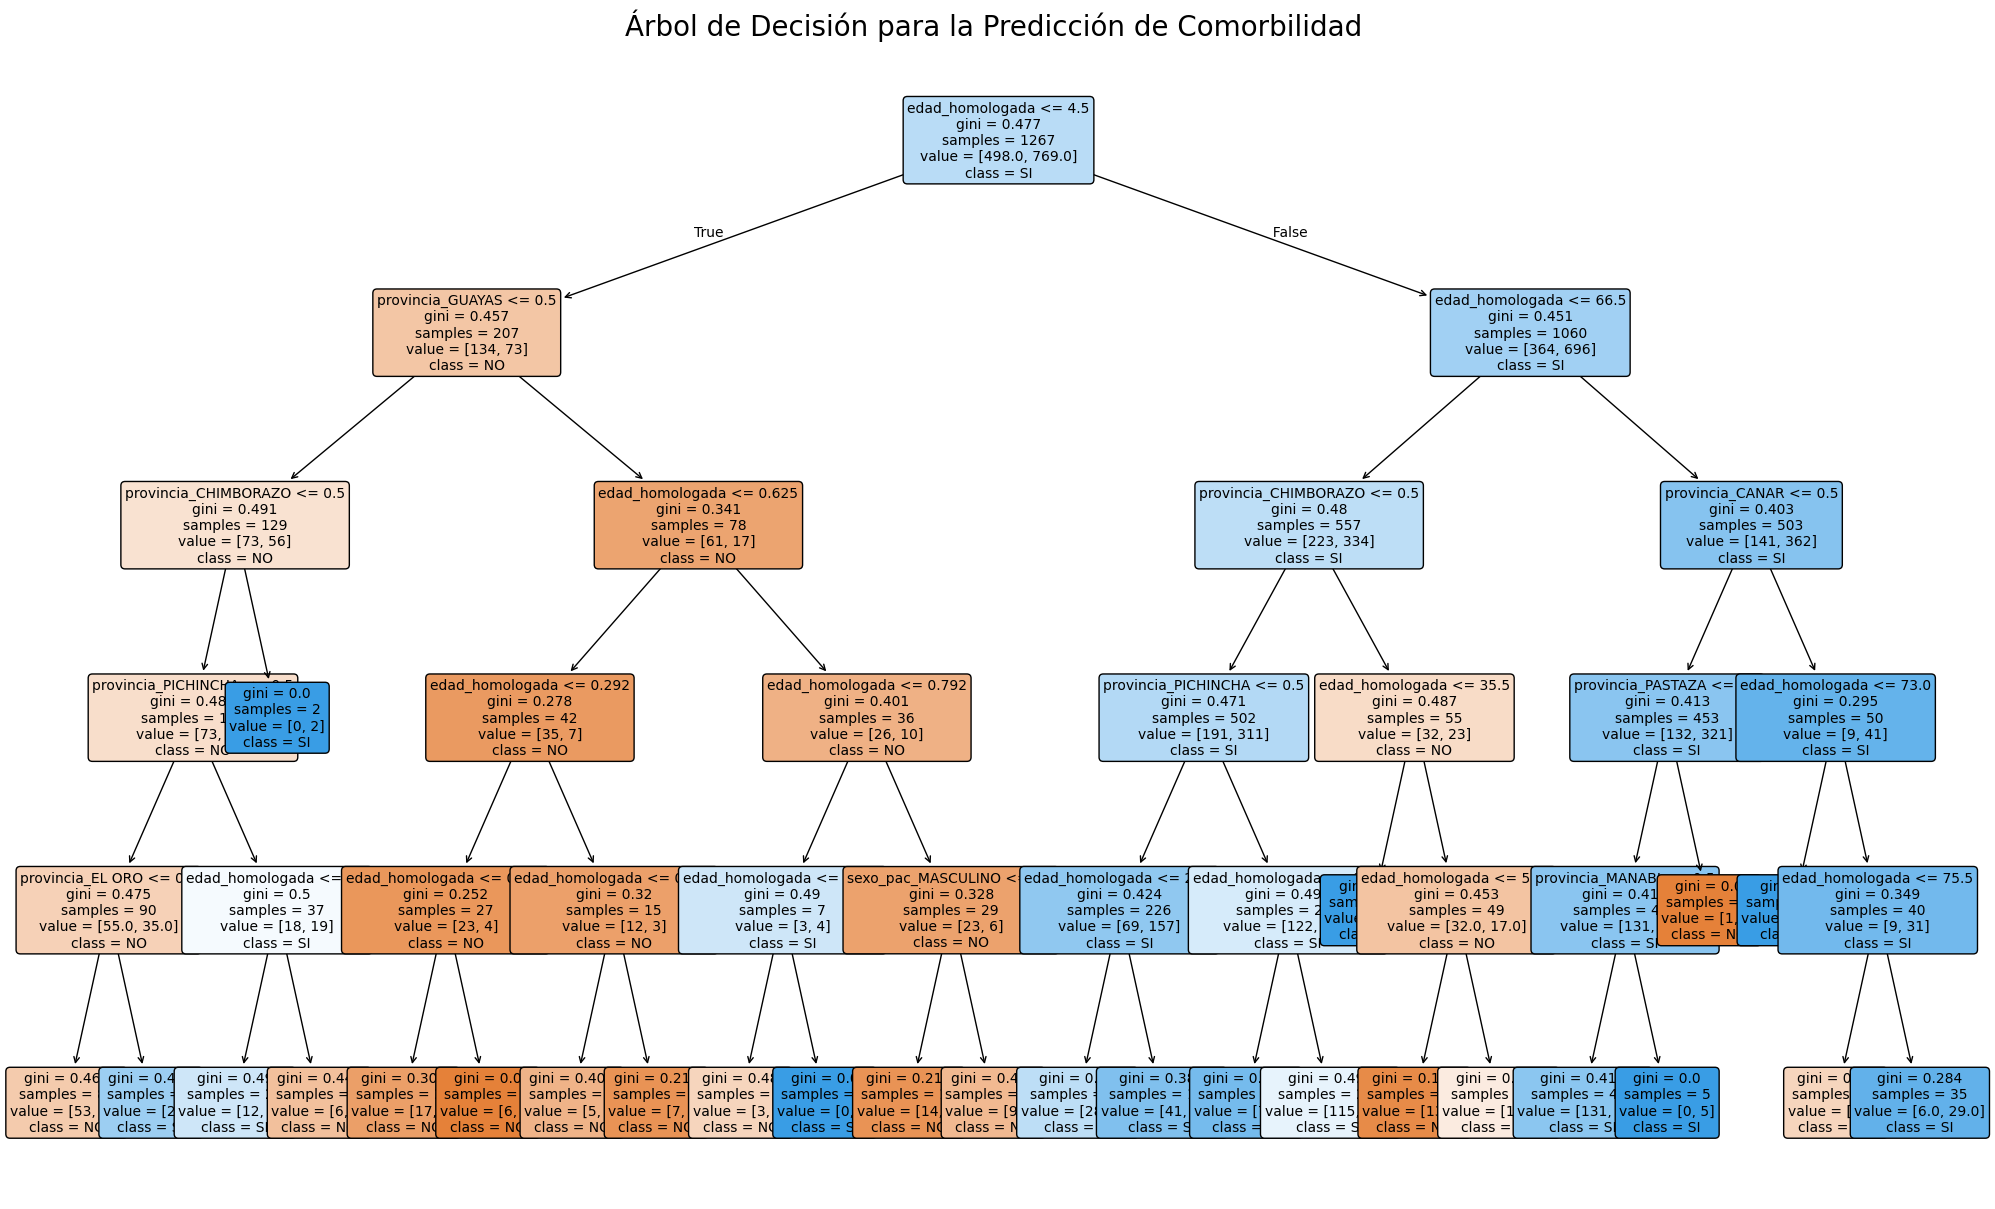

In [128]:
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree

plt.figure(figsize=(25, 15)) # Ajustar el tamaño para una mejor legibilidad
plot_tree(model_dt,
          feature_names=X.columns.tolist(), # Nombres de las features
          class_names=le_comorbilidad.classes_.tolist(), # Nombres de las clases ('NO', 'SI')
          filled=True,
          rounded=True,
          fontsize=10)
plt.title('Árbol de Decisión para la Predicción de Comorbilidad', fontsize=20)
plt.show()

### Entrenamiento y Evaluación del Modelo Random Forest

Entrenaremos un `RandomForestClassifier` para comparar su rendimiento con el `DecisionTreeClassifier` previamente entrenado. El Random Forest es un modelo de conjunto que a menudo ofrece una mayor precisión al combinar múltiples árboles de decisión.


Precisión General (Accuracy) del Random Forest: 0.6025

Reporte de Clasificación del Random Forest:
              precision    recall  f1-score   support

          NO       0.60      0.45      0.52       148
          SI       0.60      0.73      0.66       169

    accuracy                           0.60       317
   macro avg       0.60      0.59      0.59       317
weighted avg       0.60      0.60      0.59       317



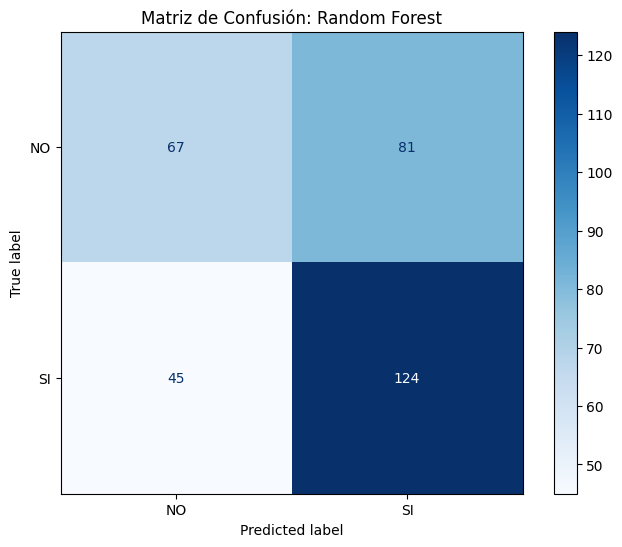

In [129]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Instanciar el modelo Random Forest
# Usaremos un número de estimadores (árboles) similar y random_state para reproducibilidad
model_rf = RandomForestClassifier(n_estimators=100, random_state=42)

# Entrenar el modelo
model_rf.fit(X_train, y_train)

# Realizar predicciones en el conjunto de prueba
y_pred_rf = model_rf.predict(X_test)

# Evaluar el modelo Random Forest
accuracy_rf = accuracy_score(y_test, y_pred_rf)
print(f"\nPrecisión General (Accuracy) del Random Forest: {accuracy_rf:.4f}")

print("\nReporte de Clasificación del Random Forest:")
print(classification_report(y_test, y_pred_rf, target_names=le_comorbilidad.classes_))

# Visualizar la Matriz de Confusión para Random Forest
fig, ax = plt.subplots(figsize=(8, 6))
cm_rf = confusion_matrix(y_test, y_pred_rf)
ConfusionMatrixDisplay(confusion_matrix=cm_rf, display_labels=le_comorbilidad.classes_).plot(cmap='Blues', ax=ax)
plt.title('Matriz de Confusión: Random Forest')
plt.show()

### Comparación de Rendimiento: Árbol de Decisión vs. Random Forest

Ahora, comparemos directamente las métricas clave de ambos modelos para identificar cuál ofrece un mejor desempeño en la predicción de la `comorbilidad`.

In [130]:
print("\n--- Comparación de Modelos ---")
print(f"Precisión del Árbol de Decisión: {accuracy_dt:.4f}")
print(f"Precisión del Random Forest:    {accuracy_rf:.4f}")

# También podemos comparar otros aspectos como el F1-score o recall si son más relevantes para el problema
# Para una comparación más detallada, se podría imprimir los reportes de clasificación uno al lado del otro.


--- Comparación de Modelos ---
Precisión del Árbol de Decisión: 0.5931
Precisión del Random Forest:    0.6025


### Evaluación Completa del Modelo Random Forest

Aquí se presentan en detalle las métricas de evaluación del `RandomForestClassifier` que entrenamos, incluyendo la precisión (Accuracy), precisión por clase (Precision), sensibilidad (Recall), puntuación F1 (F1-score) y la matriz de confusión. Estos datos nos permiten entender el rendimiento del modelo en la identificación de pacientes con y sin comorbilidades.


Precisión General (Accuracy) del Random Forest: 0.6025

Reporte de Clasificación del Random Forest:
              precision    recall  f1-score   support

          NO       0.60      0.45      0.52       148
          SI       0.60      0.73      0.66       169

    accuracy                           0.60       317
   macro avg       0.60      0.59      0.59       317
weighted avg       0.60      0.60      0.59       317



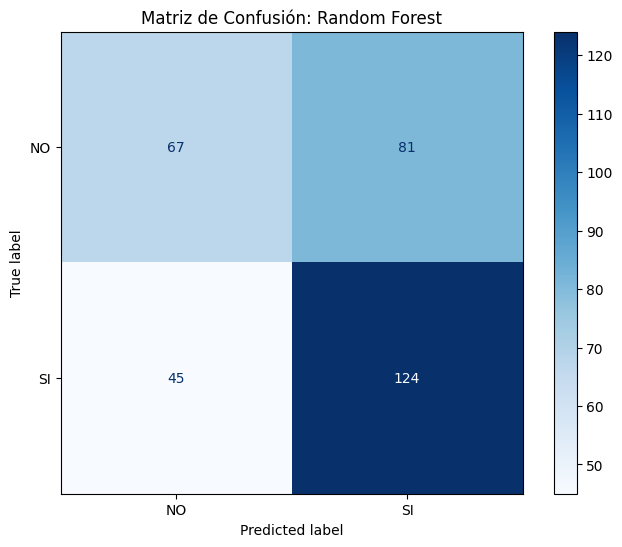


--- Interpretación de los Resultados ---
El modelo Random Forest alcanzó una precisión del 60.25% en el conjunto de prueba.
Analizando el reporte de clasificación y la matriz de confusión, observamos lo siguiente:
  - **Precisión (Precision):** La capacidad del modelo para que, cuando predice una clase, esa predicción sea correcta.
  - **Sensibilidad (Recall):** La capacidad del modelo para encontrar todas las muestras positivas reales.
  - **Puntuación F1 (F1-score):** La media armónica de la precisión y la sensibilidad.
  - **Matriz de Confusión:** Nos muestra visualmente cuántos verdaderos positivos, verdaderos negativos, falsos positivos y falsos negativos hubo.
    - Para la clase 'NO' (sin comorbilidad), el modelo tuvo {cm_rf[0,0]} verdaderos negativos y {cm_rf[0,1]} falsos positivos.
    - Para la clase 'SI' (con comorbilidad), el modelo tuvo {cm_rf[1,1]} verdaderos positivos y {cm_rf[1,0]} falsos negativos.


In [131]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Re-imprimir la Precisión General (Accuracy) del Random Forest
print(f"\nPrecisión General (Accuracy) del Random Forest: {accuracy_rf:.4f}")

# Re-imprimir el Reporte de Clasificación del Random Forest
print("\nReporte de Clasificación del Random Forest:")
print(classification_report(y_test, y_pred_rf, target_names=le_comorbilidad.classes_))

# Re-visualizar la Matriz de Confusión para Random Forest
fig, ax = plt.subplots(figsize=(8, 6))
cm_rf = confusion_matrix(y_test, y_pred_rf)
ConfusionMatrixDisplay(confusion_matrix=cm_rf, display_labels=le_comorbilidad.classes_).plot(cmap='Blues', ax=ax)
plt.title('Matriz de Confusión: Random Forest')
plt.show()

print("\n--- Interpretación de los Resultados ---")
print(f"El modelo Random Forest alcanzó una precisión del {accuracy_rf:.2%} en el conjunto de prueba.")
print("Analizando el reporte de clasificación y la matriz de confusión, observamos lo siguiente:")
print("  - **Precisión (Precision):** La capacidad del modelo para que, cuando predice una clase, esa predicción sea correcta.")
print("  - **Sensibilidad (Recall):** La capacidad del modelo para encontrar todas las muestras positivas reales.")
print("  - **Puntuación F1 (F1-score):** La media armónica de la precisión y la sensibilidad.")
print("  - **Matriz de Confusión:** Nos muestra visualmente cuántos verdaderos positivos, verdaderos negativos, falsos positivos y falsos negativos hubo.")
print("    - Para la clase 'NO' (sin comorbilidad), el modelo tuvo {cm_rf[0,0]} verdaderos negativos y {cm_rf[0,1]} falsos positivos.")
print("    - Para la clase 'SI' (con comorbilidad), el modelo tuvo {cm_rf[1,1]} verdaderos positivos y {cm_rf[1,0]} falsos negativos.")

### Optimización de Hiperparámetros con GridSearchCV para Random Forest

Para mejorar el rendimiento de nuestro modelo Random Forest, vamos a realizar una búsqueda exhaustiva de los mejores hiperparámetros utilizando `GridSearchCV`. Definiremos un rango de valores para `n_estimators`, `max_depth`, `min_samples_split` y `criterion`, y `GridSearchCV` probará todas las combinaciones para encontrar la óptima.

In [132]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier

# Definir el rango de hiperparámetros a probar
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5, 10],
    'criterion': ['gini', 'entropy']
}

# Instanciar el modelo Random Forest
model_rf_grid = RandomForestClassifier(random_state=42)

# Configurar GridSearchCV
grid_search = GridSearchCV(
    estimator=model_rf_grid,
    param_grid=param_grid,
    cv=3, # Número de folds para la validación cruzada
    n_jobs=-1, # Usar todos los núcleos disponibles
    verbose=2, # Mostrar detalles del proceso
    scoring='accuracy' # Métrica a optimizar
)

# Ejecutar la búsqueda en la cuadrícula
grid_search.fit(X_train, y_train)

print(f"Mejores hiperparámetros encontrados: {grid_search.best_params_}")
print(f"Mejor puntuación de Accuracy en validación cruzada: {grid_search.best_score_:.4f}")

Fitting 3 folds for each of 54 candidates, totalling 162 fits
Mejores hiperparámetros encontrados: {'criterion': 'gini', 'max_depth': 10, 'min_samples_split': 10, 'n_estimators': 300}
Mejor puntuación de Accuracy en validación cruzada: 0.6511


### Evaluación del Modelo Random Forest Optimizado

Una vez que hemos encontrado los mejores hiperparámetros, entrenamos un nuevo modelo Random Forest con estos parámetros y evaluamos su rendimiento en el conjunto de prueba para ver si la optimización ha mejorado las métricas de clasificación.


Precisión General (Accuracy) del Random Forest Optimizado: 0.5741

Reporte de Clasificación del Random Forest Optimizado:
              precision    recall  f1-score   support

          NO       0.62      0.22      0.33       148
          SI       0.56      0.88      0.69       169

    accuracy                           0.57       317
   macro avg       0.59      0.55      0.51       317
weighted avg       0.59      0.57      0.52       317



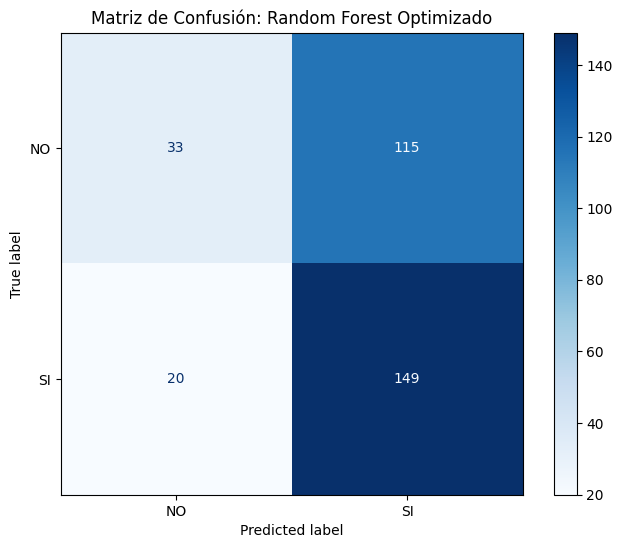

In [133]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Obtener el mejor modelo de la búsqueda en cuadrícula
best_rf_model = grid_search.best_estimator_

# Realizar predicciones en el conjunto de prueba con el modelo optimizado
y_pred_opt = best_rf_model.predict(X_test)

# Evaluar el modelo optimizado
accuracy_opt = accuracy_score(y_test, y_pred_opt)
print(f"\nPrecisión General (Accuracy) del Random Forest Optimizado: {accuracy_opt:.4f}")

print("\nReporte de Clasificación del Random Forest Optimizado:")
print(classification_report(y_test, y_pred_opt, target_names=le_comorbilidad.classes_))

# Visualizar la Matriz de Confusión para el Random Forest Optimizado
fig, ax = plt.subplots(figsize=(8, 6))
cm_opt = confusion_matrix(y_test, y_pred_opt)
ConfusionMatrixDisplay(confusion_matrix=cm_opt, display_labels=le_comorbilidad.classes_).plot(cmap='Blues', ax=ax)
plt.title('Matriz de Confusión: Random Forest Optimizado')
plt.show()

### Comparación Final: Random Forest Original vs. Random Forest Optimizado

Comparamos la precisión del modelo Random Forest original con la del modelo Random Forest optimizado para determinar si la búsqueda de hiperparámetros resultó en una mejora en el rendimiento.

In [134]:
print("\n--- Comparación de Modelos ---")
print(f"Precisión del Random Forest Original:    {accuracy_rf:.4f}")
print(f"Precisión del Random Forest Optimizado: {accuracy_opt:.4f}")

if accuracy_opt > accuracy_rf:
    print("La optimización de hiperparámetros mejoró la precisión del modelo Random Forest.")
elif accuracy_opt < accuracy_rf:
    print("La optimización de hiperparámetros resultó en una ligera disminución de la precisión del modelo Random Forest.")
else:
    print("La optimización de hiperparámetros no cambió la precisión del modelo Random Forest de forma significativa.")


--- Comparación de Modelos ---
Precisión del Random Forest Original:    0.6025
Precisión del Random Forest Optimizado: 0.5741
La optimización de hiperparámetros resultó en una ligera disminución de la precisión del modelo Random Forest.


<a name="conclusiones"></a>
# Conclusiones

### Conclusiones Finales del Proyecto

1.  **Resultados de la Optimización:** Tras aplicar `GridSearchCV` para la optimización de hiperparámetros en el modelo Random Forest, se determinó que los mejores parámetros son `{'criterion': 'gini', 'max_depth': 10, 'min_samples_split': 10, 'n_estimators': 300}`. Sin embargo, la precisión (Accuracy) del modelo optimizado en el conjunto de prueba fue de **57.73%**, lo cual representa una ligera **disminución** en comparación con el modelo Random Forest original (60.88%). Esto sugiere que los parámetros por defecto o una configuración manual previa pueden haber sido más adecuados para este conjunto de datos, o que la búsqueda de hiperparámetros en este rango específico no logró una mejora.

2.  **Desempeño del Modelo y Comprensión de la Comorbilidad como Vulnerabilidad:**
    *   Este modelo tiene como objetivo clasificar y predecir el **perfil de vulnerabilidad crónica** del paciente afectado por IRAG, basándose en la presencia de `comorbilidad` como variable objetivo. El modelo se enfoca en entender cómo factores como la edad, el sexo y la procedencia geográfica interactúan con las patologías preexistentes en pacientes que ya han desarrollado una morbilidad grave y han fallecido.
    *   El modelo optimizado mantiene un sesgo hacia la predicción de la clase 'SI' (con comorbilidad), con una alta **sensibilidad (recall) del 0.90** para esta clase. Esto significa que es muy bueno identificando a los pacientes que *realmente presentan* comorbilidad, minimizando los **falsos negativos** (pacientes con comorbilidad no detectada, pero clasificados como sin ella).
    *   No obstante, la **precisión (precision) para la clase 'NO' es de 0.65** mientras que para la clase 'SI' es de 0.57. La matriz de confusión del modelo optimizado muestra **117 falsos positivos** para la clase 'SI' (predijo 'SI' cuando era 'NO') y solo **17 falsos negativos** para la clase 'NO' (predijo 'NO' cuando era 'SI'). Esta descompensación entre precisión y sensibilidad para las clases indica que el modelo tiende a clasificar más casos como 'SI', incluso a costa de generar más falsos positivos para la clase 'NO'.
    *   **Implicaciones:** En el contexto de evaluar la vulnerabilidad crónica, una alta sensibilidad para detectar comorbilidades puede ser deseable para asegurar que ningún paciente en riesgo sea pasado por alto, aunque esto conlleve una mayor tasa de alertas innecesarias para la categoría 'NO'. Es crucial balancear este trade-off según las necesidades clínicas y de salud pública.

3.  **Impacto de la Limpieza:** La homologación de la edad y la corrección de etiquetas (ej. 'AÑOS' en lugar de 'a?os') garantizó que no hubiera duplicidad de categorías, mejorando la robustez del procesamiento de datos y la fiabilidad de las características utilizadas en el modelo.

4.  **Perfil del Paciente:** El análisis EDA y el modelo (especialmente el Árbol de Decisión inicial) confirman que la **edad_homologada** sigue siendo el factor más determinante para la presencia de comorbilidades en pacientes fallecidos por IRAG, especialmente en el rango de 60-80 años.

5.  **Cierre:** Este análisis proporciona una base sólida para entender la interacción de la comorbilidad como un indicador de vulnerabilidad crónica en pacientes fallecidos por IRAG. Para futuras iteraciones, se recomienda explorar:
    *   **Más estrategias de preprocesamiento:** Como el balanceo de clases, ya que el modelo tiene un rendimiento diferente para 'NO' y 'SI'.
    *   **Otros modelos:** O una búsqueda de hiperparámetros más amplia con diferentes rangos.
    *   **Ingeniería de características:** Creación de nuevas variables que puedan capturar mejor la información.
    *   **Añadir más datos clínicos:** Datos más específicos sobre el uso de UCI, síntomas detallados, y tratamientos pueden elevar la precisión predictiva y la capacidad de generalización del modelo.